In [120]:
# to_save, to_load = False, True
session_file = "./tmp/TIC_188835620_EA_ROT.ipynb.pkl"

# # load/save the notebook session
# # https://dill.readthedocs.io/en/latest/
# if True: 
#     import sys
#     if "../" not in sys.path:  # to get my usual helpers at base dir
#         sys.path.append("../")
#     if "../eb_with_diff_sb_period/etv/" not in sys.path:  # for etvp
#         sys.path.append("../eb_with_diff_sb_period/etv/")
#     import dill
#     dill.load_module(session_file)
#     print(f"Notebook session loaded from  {session_file}")
#     %matplotlib inline


# if True:  # save the notebook session
#     import dill
#     dill.dump_module(session_file)
#     print(f"Notebook session saved in {session_file}")


Notebook session saved in ./tmp/TIC_188835620_EA_ROT.ipynb.pkl


In [2]:
import sys
if "../" not in sys.path:  # to get my usual helpers at base dir
    sys.path.append("../")

import lightkurve as lk
from lightkurve_ext import of_sector, of_sectors, of_2min_cadences
import lightkurve_ext as lke
from lightkurve_ext import TransitTimeSpec, TransitTimeSpecList
import lightkurve_ext_tess as lket
import lightkurve_ext_pg as lke_pg
import lightkurve_ext_pg_runner as lke_pg_runner
import tic_plot as tplt

import asyncio_compat

import math
import re
import warnings

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as matplotlib

import pandas as pd
import astropy as astropy
from astropy import units as u
from astropy.coordinates import SkyCoord
from astropy.time import Time, TimeDelta
from astropy.io import fits

from matplotlib.ticker import (FormatStrFormatter, AutoMinorLocator)

from importlib import reload # useful during development to reload packages

from IPython.display import display, HTML, Javascript, clear_output

display(HTML("<style>.container { width:99% !important; }</style>"))  # Jupyter 6
display(HTML("<style>.jp-Notebook { --jp-notebook-max-width: 98%; }</style>"))  # Jupyter 7


# No longer works in Jupyter 7+
display(Javascript("""
// export notebook url to Python for bokeh-based interactive features
if (window["IPython"] != null) {
  IPython.notebook.kernel.execute(`notebook_url = "${window.location.origin}"`);
} else {
  console.warn("IPython js object not available (in Jupyter 7). Hardcode notebook_url in the notebook itself instead.")
}
"""));
notebook_url = "localhost:8888"

%matplotlib inline

# data cache config
lk_download_dir = '../data'
if hasattr(lk, "conf"):  # default download dir
    lk.conf.cache_dir = lk_download_dir

# make markdown table aligned to the left of the cell output (instead of center)
display(HTML("<style>table {margin-left: 4ch;}</style>"))

C:\pkg\_winNonPortables\miniforge3\envs\my_lk_plus4\Lib\site-packages\lightkurve\prf\__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(
C:\pkg\_winNonPortables\miniforge3\envs\my_lk_plus4\Lib\site-packages\lightkurve\config\__init__.py:119: UserWarning: The default Lightkurve cache directory, used by download(), etc., has been moved to C:\Users\SL\.lightkurve\cache. Please move all the files in the legacy directory C:\Users\SL\.lightkurve-cache to the new location and remove the legacy directory. Refer to https://lightkurve.github.io/lightkurve/reference/config.html#default-cache-directory-migration for more information.
  warnings.warn(


<IPython.core.display.Javascript object>

# TIC 188835620  Analysis (EA+ROT)

- new VSX entry


## TESS Data

In [3]:
tic = 188835620

sr = lk.search_lightcurve(f"TIC{tic}", )  # author="SPOC", cadence="short"
sr_unfiltered = sr  # keep a copy
sr = lke.filter_by_priority(sr, author_priority = ["QLP"])  # use QLP that keep better rotational data, alternative is SPOC SAP_FLUX  # "SPOC", "TESS-SPOC", 
# sr = sr[np.isin(sr.author, ["SPOC", "TESS-SPOC"])]  
sr = lke._sort_chronologically(sr)

astropy.table.pprint.conf.max_lines = 100  # to print all rows
display(sr)

# Note: only 1 sector of ready made lightcurve
# if needed, lightcurves can be created from sectors 37, 63, 64 (and in the future 90, 99, 100, 101)
lcc_tess = sr.download_all()
lcc_tess

#,mission,year,author,exptime,target_name,distance,proposal_id
,,,,s,,arcsec,
0,TESS Sector 14,2019,QLP,1800,188835620,0.0,N/A
1,TESS Sector 17,2019,QLP,1800,188835620,0.0,N/A
2,TESS Sector 24,2020,QLP,1800,188835620,0.0,N/A
3,TESS Sector 25,2020,QLP,1800,188835620,0.0,N/A
4,TESS Sector 26,2020,QLP,1800,188835620,0.0,N/A
5,TESS Sector 40,2021,QLP,600,188835620,0.0,N/A
6,TESS Sector 47,2021,QLP,600,188835620,0.0,N/A
7,TESS Sector 51,2022,QLP,600,188835620,0.0,N/A
8,TESS Sector 52,2022,QLP,600,188835620,0.0,N/A


LightCurveCollection of 21 objects:
    0: <TessLightCurve LABEL="TIC 188835620" SECTOR=14 AUTHOR=QLP FLUX_ORIGIN=sap_flux>
    1: <TessLightCurve LABEL="TIC 188835620" SECTOR=17 AUTHOR=QLP FLUX_ORIGIN=sap_flux>
    2: <TessLightCurve LABEL="TIC 188835620" SECTOR=24 AUTHOR=QLP FLUX_ORIGIN=sap_flux>
    3: <TessLightCurve LABEL="TIC 188835620" SECTOR=25 AUTHOR=QLP FLUX_ORIGIN=sap_flux>
    4: <TessLightCurve LABEL="TIC 188835620" SECTOR=26 AUTHOR=QLP FLUX_ORIGIN=sap_flux>
    5: <TessLightCurve LABEL="TIC 188835620" SECTOR=40 AUTHOR=QLP FLUX_ORIGIN=sap_flux>
    6: <TessLightCurve LABEL="TIC 188835620" SECTOR=47 AUTHOR=QLP FLUX_ORIGIN=sap_flux>
    7: <TessLightCurve LABEL="TIC 188835620" SECTOR=51 AUTHOR=QLP FLUX_ORIGIN=sap_flux>
    8: <TessLightCurve LABEL="TIC 188835620" SECTOR=52 AUTHOR=QLP FLUX_ORIGIN=sap_flux>
    9: <TessLightCurve LABEL="TIC 188835620" SECTOR=53 AUTHOR=QLP FLUX_ORIGIN=sap_flux>
    10: <TessLightCurve LABEL="TIC 188835620" SECTOR=54 AUTHOR=QLP FLUX_ORIGIN=sap_f

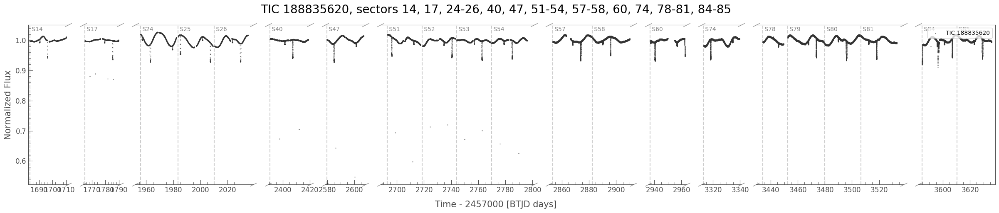

In [4]:
lc = lke.stitch(lcc_tess, ignore_incompatible_column_warning=True, )

axs = tplt.plot_skip_data_gap(lc, figsize=(30,5), s=1, alpha=0.9);
axs[0].get_figure().suptitle(f"{lc.label}, sectors {lke.abbrev_sector_list(lc)}", fontsize=20);
# [ax.set_ylim(0.85, 1.05) for ax in axs];

## Gaia DR3 info (coordinate, etc.)

In [5]:
# reload(lke)
# reload (lket)
rs_all_cols, rs, rs_html  = lket.search_gaiadr3_of_tics(tic, radius_arcsec=5, magnitude_range=None,  pm_error_factor=None, pm_range_fraction=None, pm_range_minimum=None, 
                                                        calc_separation_from_first_row=True,  # assuming the first row is the target, it'd calculate more accurately the separation for Gaia DR3 Main
                                                        compact_columns=True, also_return_html=True, also_return_astrophysical=False, verbose_html=True, include_nss_summary_in_html=False)
display(HTML(rs_html))

# from Gaia DR3
target_coord = SkyCoord(rs[0]["RAJ2000"], rs[0]["DEJ2000"], unit=(u.deg, u.deg), frame="icrs")
target_coord_dict = dict(ra=target_coord.ra.value, dec=target_coord.dec.value)


Listed as a SB1	with 32.80745 d period in Gaia DR3 NSS (model AstroSpectroSB1)  (also present in SB9)


In [6]:
primary_name = f"TIC {tic}"
print(primary_name)

TIC 188835620


## Combining all data


### TESS: remove systematics / outliers, convert to mag and HJD

In [10]:
# helper to review the data interactively
tplt.plot_transit_interactive(_lc, figsize=(30, 8), plot_kwargs=dict(normalize=False, plot_kwargs=dict(s=25),));

Output(layout=Layout(border_bottom='1px solid lightgray', border_left='1px solid lightgray', border_right='1px…

Output(layout=Layout(padding='1em'))

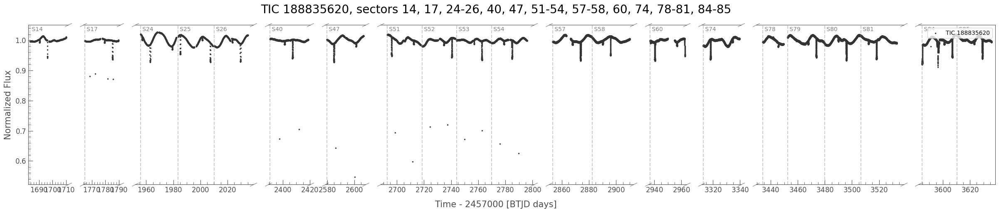

In [7]:
_lc = lke.stitch(lcc_tess, ignore_incompatible_column_warning=True,)  # corrector_func=lambda lc: lc.select_flux("sap_flux").normalize()
# _lc_all = _lc  # retain a copy
axs = tplt.plot_skip_data_gap(_lc, figsize=(30,5), s=9, alpha=0.9);
axs[0].get_figure().suptitle(f"{_lc.label}, sectors {lke.abbrev_sector_list(_lc)}", fontsize=20);

130064

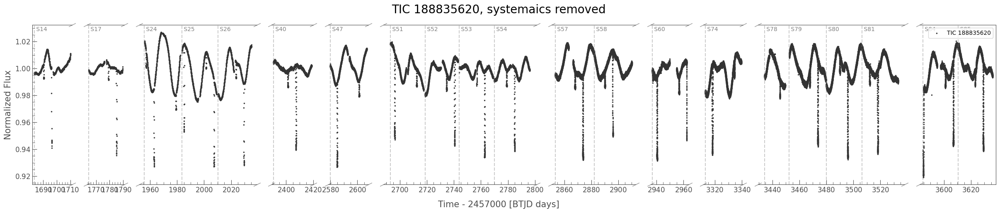

In [12]:
_lc = lke.stitch(lcc_tess, ignore_incompatible_column_warning=True,)  # corrector_func=lambda lc: lc.select_flux("sap_flux").normalize()
# remove outliers, do it in BTJD as it's more familiar to me
_lc = _lc.truncate(0.9, None, column="flux")  # remove outliers, mostly momentum dump related 1-point systematics


for xstart, xstop in [  # scattered light, and systematics
    (3595, 3597.5),
]:
    _lc = lke.exclude_range(_lc, xstart, xstop)

    
axs = tplt.plot_skip_data_gap(_lc, figsize=(30,5), s=9, alpha=0.9);
axs[0].get_figure().suptitle(f"{_lc.label}, systemaics removed", fontsize=20);

# axs = tplt.plot_skip_data_gap(_lc, figsize=(30,5), s=9, alpha=0.9);
# axs[0].get_figure().suptitle(f"{_lc.label}, eclipses truncated, systematics removed", fontsize=20);
# [ax.set_ylim(0.97, 1.01) for ax in axs];

# convert to mag and HJD
lc_tess = _lc
lc_tess = lke.to_flux_in_mag_by_normalization(lc_tess)
lc_tess = lke.convert_lc_time_to_hjd_utc(lc_tess, target_coord=target_coord, cache_dir=lk_download_dir)
len(lc_tess)


### Do Actual Combining

TESS # data points: 130064


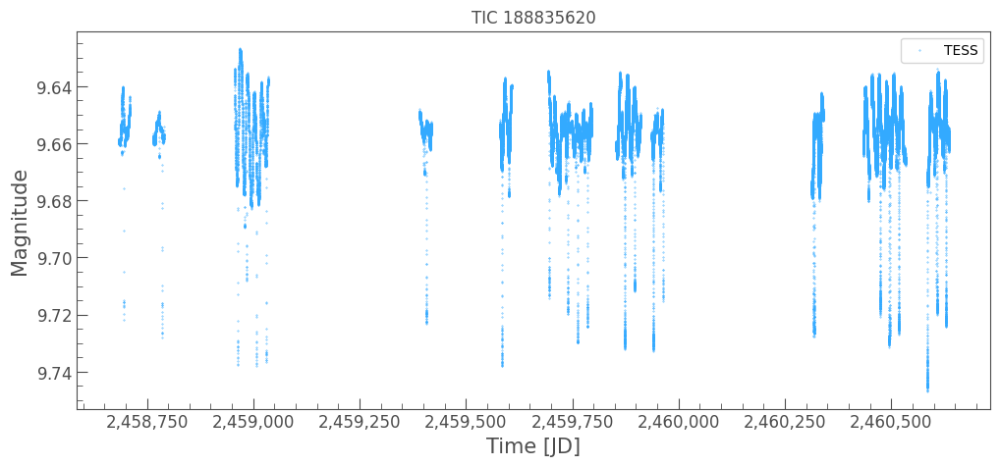

In [13]:
# Convert the data to magnitude and HJD/UTC

import lightkurve_ext_multi_sources as lkem
# reload(lkem)


lc_combined_dict = lkem.combine_multi_bands_and_shift(
    {"TESS": lc_tess, 
    }, 
    # shift_to="",
)

for k in lc_combined_dict.keys():
    print(f"{k} # data points:", len(lc_combined_dict[k]))

plot_options = lkem.get_default_plot_multi_bands_options_copy()
# for TESS plot (index 0) move it to the front
plot_options[0][1]["zorder"] = 9  # default 2

ax = lkem.plot_multi_bands(lc_combined_dict, figsize=(12, 5), target_name=primary_name, plot_options=plot_options);
# ax.set_ylim(9.2, 8.75);


##  Eclipse epoch / period / duration

- use TESS data only, eclipses not found in the others

### Initial epoch / period / duration


Adopted period / epoch / duration_hr:  22.2167 2459407.27 12.0
Min II phase: 0.7337


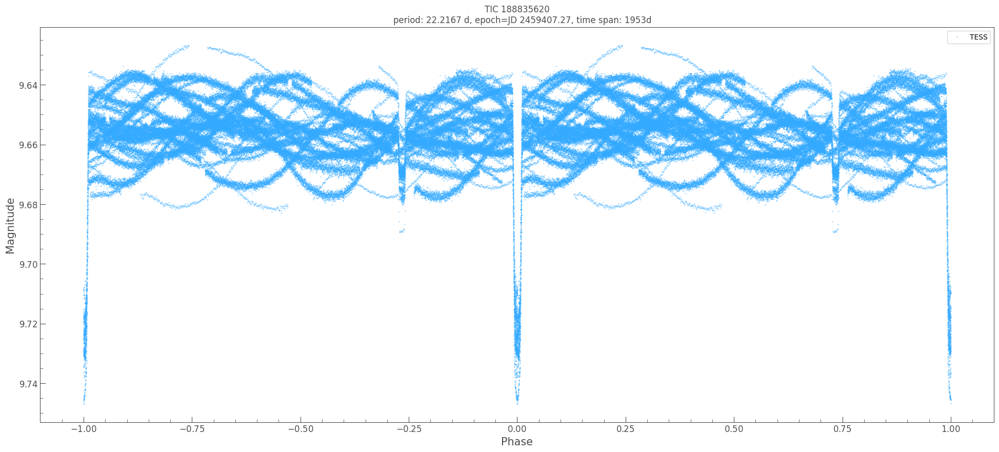

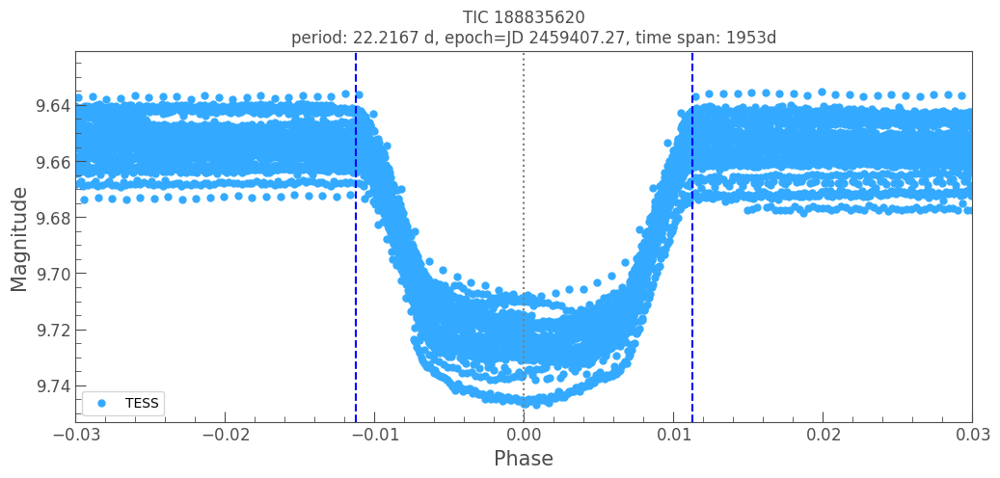

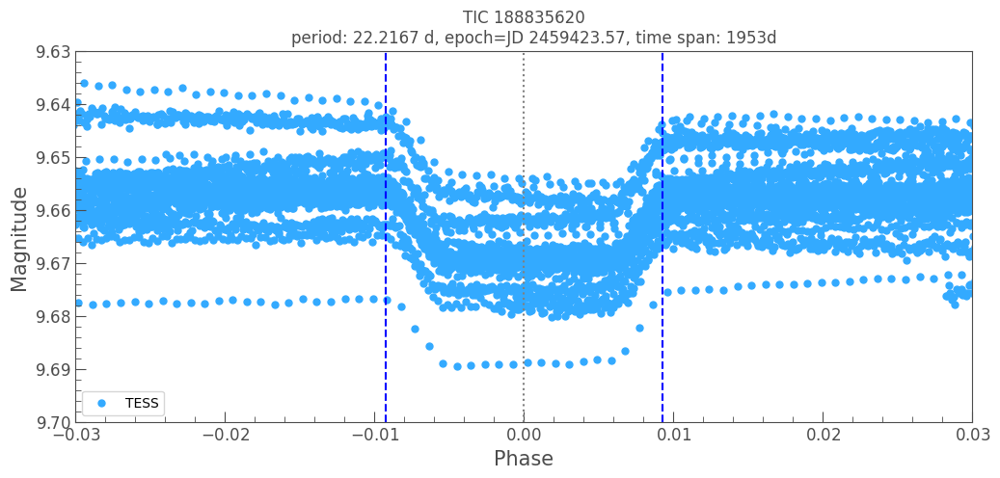

In [15]:
# from TCE
# https://mast.stsci.edu/api/v0.1/Download/file/?uri=mast:TESS/product/tess2019199201929-s0014-s0086-0000000188835620-01-00971_dvs.pdf
# epoch=2407.27, duration_hr=12.0144, period=22.2167, label="s0014s0086tce1", transit_depth_percent=6.2178,
# min_ii_epoch= +16.30 

period_trial = 22.2167  # TCE
epoch_time_hjd_trial = round(lket.btjd_to_hjd_utc(2407.27, target_coord), 2)
duration_hr_min_i_trial = 12.0

print("Adopted period / epoch / duration_hr: ", period_trial, epoch_time_hjd_trial, duration_hr_min_i_trial)

epoch_time_min_ii_hjd_trial = epoch_time_hjd_trial + 16.30
epoch_phase_min_ii_trial   = abs(epoch_time_min_ii_hjd_trial   - epoch_time_hjd_trial  ) / period_trial   % 1
epoch_phase_min_ii_trial  = round(epoch_phase_min_ii_trial  , 4)  # precsion from eyeballing zoomed plot
print("Min II phase:", epoch_phase_min_ii_trial)

duration_hr_min_ii_trial = 9.9

# --- Plot them to verify ---

ax, lc_f_res = lkem.fold_n_plot_multi_bands(
    lc_combined_dict,  # {"TESS": lc_tess},
    period=period_trial,
    epoch=Time(epoch_time_hjd_trial   , format="jd", scale="utc"),
    phase_scale=2,  #  fold at  period, i.e., plot from phase -1 to +1    
    figsize=(24, 10),
    target_name=primary_name,
    # plot_options=plot_options,
);


# zoom plot Min I
# - make TESS more visible:  larger dots
plot_options_zoom = lkem.get_default_plot_multi_bands_options_copy()
plot_options_zoom[0][1]["s"] = 25
ax, lc_f_res = lkem.fold_n_plot_multi_bands(
    lc_combined_dict,  # {"TESS": lc_tess},
    period=period_trial  ,
    epoch=Time(epoch_time_hjd_trial   , format="jd", scale="utc"),
    phase_scale=2,  #  fold at  period, i.e., plot from phase -1 to +1
    target_name=primary_name,
    duration_hr=duration_hr_min_i_trial  ,  # for plotting only
    figsize=(12, 5),
    plot_options=plot_options_zoom,
    # mag_shift_precision=2,  #
);
ylim = (None, None)
ax.set_ylim(*ylim);
ax.legend(loc="lower left");
ax.axvline(0, c="gray", linestyle="dotted");
ax.set_xlim(-0.03, 0.03);  # to see primary in details



# zoom plot Min II
ax, lc_f_res = lkem.fold_n_plot_multi_bands(
    lc_combined_dict,  # {"TESS": lc_tess},
    period=period_trial  ,
    epoch=Time(epoch_time_min_ii_hjd_trial   , format="jd", scale="utc"),
    phase_scale=2,  #  fold at  period, i.e., plot from phase -1 to +1
    target_name=primary_name,
    duration_hr=duration_hr_min_ii_trial  ,  # for plotting only
    figsize=(12, 5),
    plot_options=plot_options_zoom,
    # mag_shift_precision=2,  #
);
ylim_min_ii = (9.7, 9.63)
ax.set_ylim(*ylim_min_ii);
ax.legend(loc="lower left");
ax.axvline(0, c="gray", linestyle="dotted");
ax.set_xlim(-0.03, 0.03);  # to see secondary in details
# ax.set_xlim(epoch_phase_min_ii_trial -0.03, epoch_phase_min_ii_trial + 0.03);  # to see secondary in details


### Refine the period with MCMC on primary eclipses  - N/A


In [ ]:
# # reload(lke)

# _lc = lke.to_normalized_flux_from_mag(lc_tess.remove_nans())

# lc_f_min_i = _lc.fold(epoch_time=epoch_time_hjd_trial, period=period_trial, normalize_phase=True)
# lc_f_min_i = lc_f_min_i.truncate((0 - duration_hr_min_i_trial / 24 * 0.4) / period_trial, (0 + duration_hr_min_i_trial /24 * 0.4) / period_trial)
# # ax1 = tplt.scatter(lc_f_min_i, c=lc_f_min_i.time_original.value, s=25);
# ax1 = tplt.errorbar(lc_f_min_i);



In [ ]:
# from types import SimpleNamespace

# import sys
# if "../eb_with_diff_sb_period/etv/" not in sys.path:  # for etvp
#     sys.path.append("../eb_with_diff_sb_period/etv/")

# import etv_functions_with_period as etvp
# import etv_functions
# # reload(etv_functions)

# lc_f = lc_f_min_i

# # # median flux, -eclipse depth, t0, related to duration, related to shape (U or V) 
# # # t0 in normalixed phase
# start_vals = [1.0, -0.105, 0, 0.0015, 1.0]


# # convert lc to the form needed by fit etv_functions
# lc_f_data = SimpleNamespace(time=lc_f.time_original.value, phase=lc_f.time.value, flux=np.array(lc_f.flux.value), err=np.array(lc_f.flux_err.value))
# etv_functions.plot_initial_guess_interactive(lc_f_data, None, None, None, "0", *start_vals)

In [ ]:
# mean_alpha0, mean_alpha1, mean_t0_time, mean_d, mean_Tau, mean_p, fit_params_p_stats  = etvp.run_mcmc_initial_fit_p(
#     lc_f_data, 
#     [1.0, -0.105, epoch_time_hjd_trial, 0.0015, 1.0, period_trial],
#     # nruns=20, discard=1,
#     nruns=4000, discard=1000,
#     autocorr_time_kwargs=dict(tol=20),  # the emcee defaults tol=50 seems to be too strict for our use case, tol of ~10 - 20 seems to be sufficient    
#     pool=-2, 
#     plot_chains=True, plot_autocorrelation=True, plot=True, 
#     also_return_stats=True,
# )

# print("mean_alpha0, mean_alpha1, mean_t0_time, mean_d, mean_Tau, mean_p = " + ", ".join([str(v) for v in [mean_alpha0, mean_alpha1, mean_t0_time, mean_d, mean_Tau, mean_p]]))
# print("std_t0:", fit_params_p_stats["std_t0"])
# print("std_p:", fit_params_p_stats["std_p"])


### Final epoch / period / duration


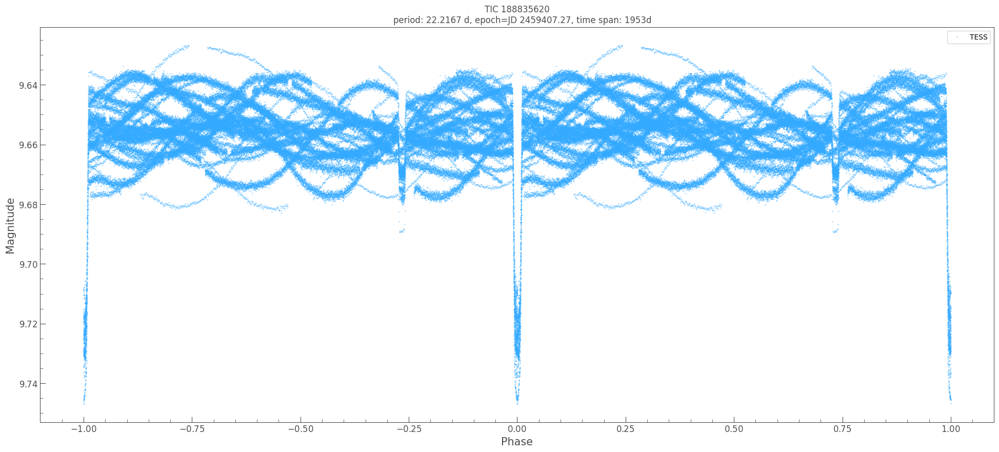

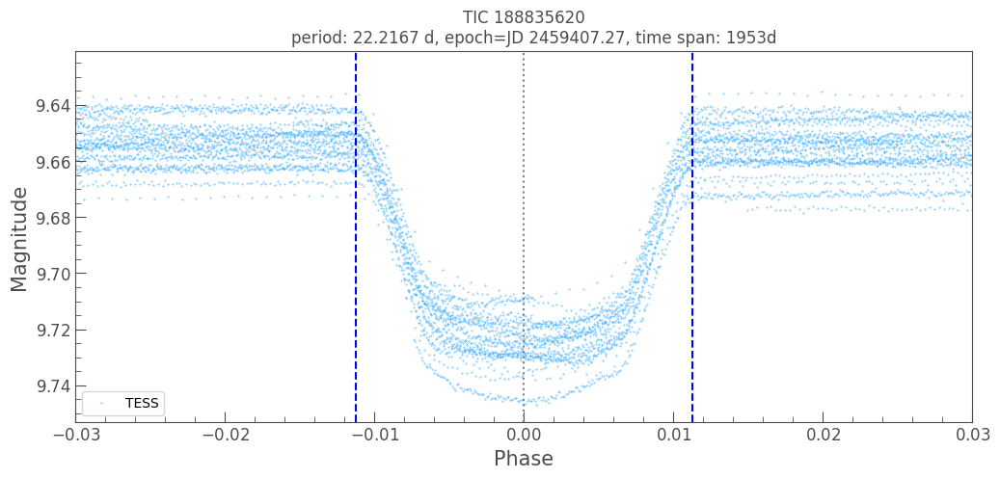

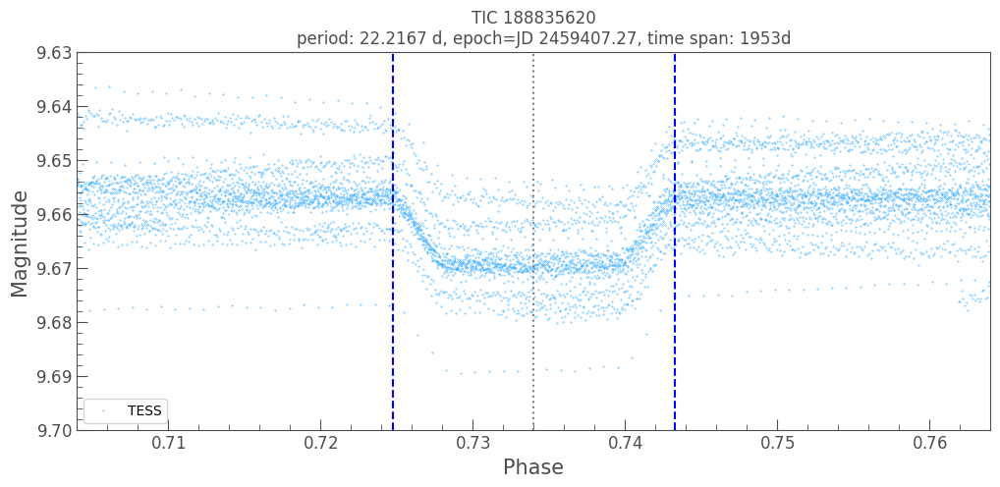

In [111]:
# Cannot tell the difference between TCE period and BLS period, cut 1 digit and choose the best
period_final = period_trial
epoch_time_hjd_final = epoch_time_hjd_trial
duration_hr_min_i_final = duration_hr_min_i_trial

epoch_time_min_ii_hjd_final = epoch_time_min_ii_hjd_trial
epoch_phase_min_ii_final   = (epoch_time_min_ii_hjd_final  - epoch_time_hjd_final ) / period_final   % 1
epoch_phase_min_ii_final  = round(epoch_phase_min_ii_final, 3)  # precsion from eyeballing zoomed plot
duration_hr_min_ii_final = duration_hr_min_ii_trial


# --- Plot them to verify ---

ax, lc_f_res = lkem.fold_n_plot_multi_bands(
    {"TESS": lc_tess},
    period=period_final,
    epoch=Time(epoch_time_hjd_final   , format="jd", scale="utc"),
    phase_scale=2,  #  fold at  period, i.e., plot from phase -1 to +1    
    figsize=(24, 10),
    target_name=primary_name,
    # plot_options=plot_options,
);
# ylim = (None, None)
ax.set_ylim(*ylim);


# zoom plot Min I
# - make TESS more visible:  larger dots
plot_options_zoom = lkem.get_default_plot_multi_bands_options_copy()
# plot_options_zoom[0][1]["s"] = 9
# plot_options_zoom[2][1]["zorder"] = 9
ax, lc_f_res = lkem.fold_n_plot_multi_bands(
    lc_combined_dict,  # {"TESS": lc_tess},
    period=period_final  ,
    epoch=Time(epoch_time_hjd_final   , format="jd", scale="utc"),
    phase_scale=2,  #  fold at  period, i.e., plot from phase -1 to +1
    target_name=primary_name,
    duration_hr=duration_hr_min_i_final  ,  # for plotting only
    figsize=(12, 5),
    plot_options=plot_options_zoom,
    # mag_shift_precision=2,  #
);
ax.set_ylim(*ylim);
ax.legend(loc="lower left");
ax.axvline(0, c="gray", linestyle="dotted");
ax.set_xlim(-0.03, 0.03);  # to see primary in details


# zoom plot Min II
ax, lc_f_res = lkem.fold_n_plot_multi_bands(
    lc_combined_dict,  # {"TESS": lc_tess},
    period=period_final  ,
    epoch=Time(epoch_time_hjd_final, format="jd", scale="utc"),
    phase_scale=2,  #  fold at  period, i.e., plot from phase -1 to +1
    target_name=primary_name,
    duration_hr=duration_hr_min_ii_final  ,  # for plotting only
    duration_midpoint_phase=epoch_phase_min_ii_final,
    figsize=(12, 5),
    plot_options=plot_options_zoom,
    # mag_shift_precision=2,  #
);
ax.set_ylim(*ylim_min_ii);
ax.legend(loc="lower left");
ax.axvline(epoch_phase_min_ii_final, c="gray", linestyle="dotted");
ax.set_xlim(epoch_phase_min_ii_final-0.03, epoch_phase_min_ii_final+0.03);  # to see secondary in details

## Rotation epoch / period

In [ ]:
lke.stitch_lc_dict(

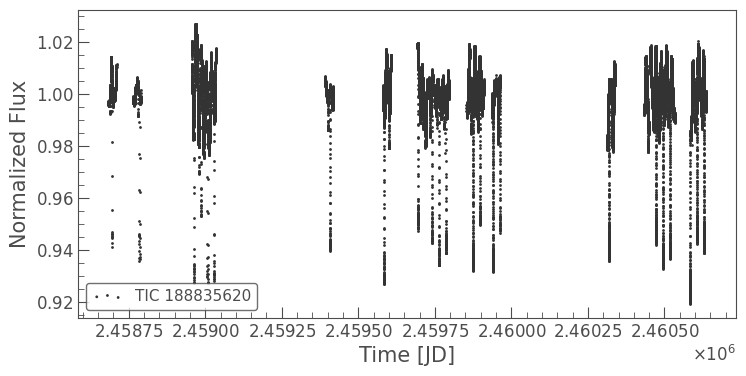

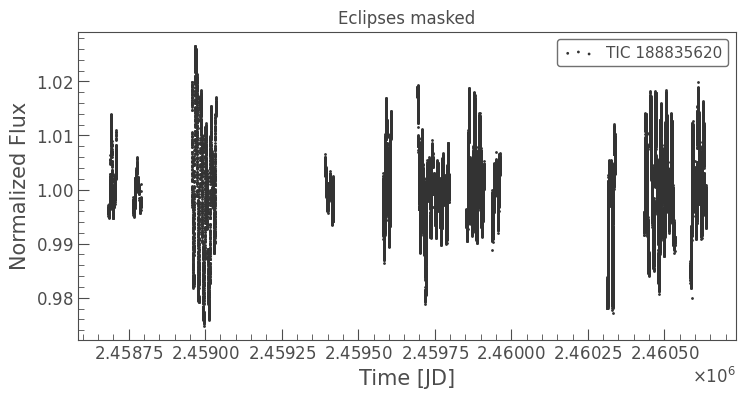

In [24]:
lc = lke.stitch_lc_dict(lc_combined_dict).remove_nans().remove_nans(column="flux_err")
ax = tplt.scatter(lc);

lc_combined_dict_no_ecl = dict()
for key, _lc in lc_combined_dict.items():
    tmask = _lc.create_transit_mask(period=period_final, transit_time=epoch_time_hjd_final, duration=duration_hr_min_i_final/24 * 1.4)
    tmask2 = _lc.create_transit_mask(period=period_final, transit_time=epoch_time_min_ii_hjd_final, duration=duration_hr_min_ii_final/24 * 1.4)
    _lc = _lc[~tmask & ~tmask2]
    lc_combined_dict_no_ecl[key] = _lc

    
lc = lke.stitch_lc_dict(lc_combined_dict_no_ecl).remove_nans().remove_nans(column="flux_err")  
# lc = lc_combined_dict_no_ecl["TESS"].remove_nans().remove_nans(column="flux_err")  # TESS only, the error of ASAS data is too great
ax = tplt.scatter(lc);
ax.set_title("Eclipses masked");

In [25]:
# helper to review the data interactively to determine rot min epoch
tplt.plot_transit_interactive(lc, figsize=(30, 8), plot_kwargs=dict(normalize=False, plot_kwargs=dict(s=25),));

Output(layout=Layout(border_bottom='1px solid lightgray', border_left='1px solid lightgray', border_right='1px…

Output(layout=Layout(padding='1em'))

### Rotation period trial / refinement

#### Trial with Lomb-Scargle, MCMC and visual inspection of candidate periods

- ANOVA skipped

In [19]:
import os; os.add_dll_directory(r"C:\msys64\mingw64\bin"); print("Added MinGW64 bin to_bytes os DLL path for my nifty-ls build.");
# from importlib import reload
# import nifty_ls
# reload(nifty_ls.core)  # to ensure available backend are not cached with old values
# nifty_ls.__version__

Added MinGW64 bin to_bytes os DLL path for my nifty-ls build.


In [26]:
pg = (
    lc
    # lke.to_normalized_flux_from_mag(lc_tess)
    .to_periodogram(method="lombscargle",
                    ls_method="fastnifty",
                    # minimum_period=0.5, maximum_period=100,
                    oversample_factor=50,  # default: 5
                      )
     )
print(len(lc), lc.time.max() - lc.time.min(), lc.time.min(), lc.time.max(), )
pg.show_properties();

print("period_at_max_power:", pg.period_at_max_power, "/", pg.frequency_at_max_power.to(u.microhertz))


123405 1952.6747431866825 2458683.364623399 2460636.0393665857
lightkurve.Periodogram properties:
      Attribute           Description    Units
---------------------- ----------------- -----
                nterms                 1      
              targetid         188835620      
          default_view         frequency      
                 label     TIC 188835620      
             ls_method         fastnifty      
frequency_at_max_power             0.059 1 / d
             max_power            0.0085      
               nyquist          216.0008 1 / d
   period_at_max_power           16.9415     d
             frequency array (21088963,) 1 / d
                period array (21088963,)     d
                 power array (21088963,)      
                  meta    <class 'dict'>      
period_at_max_power: 16.94147790375397 d / 0.6831797166591611 uHz


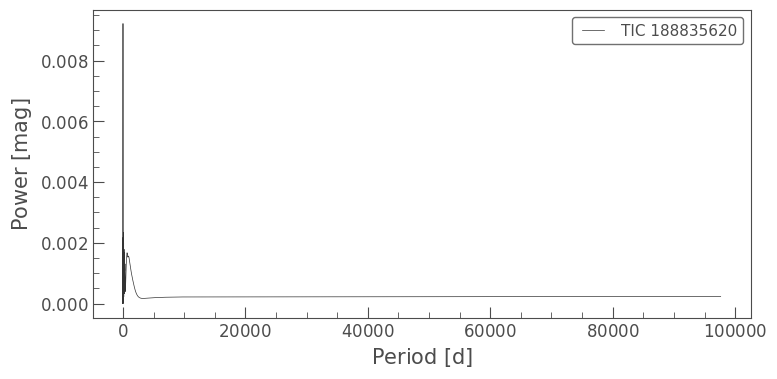

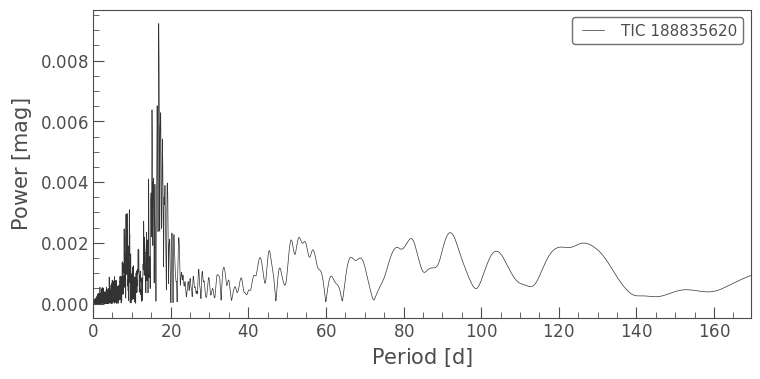

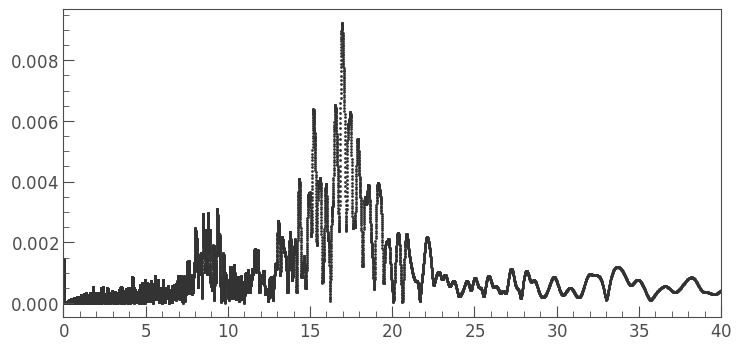

In [21]:
ax = pg.plot(view="period"); 

ax = pg.plot(view="period"); 
ax.set_xlim(0, pg.period_at_max_power.value * 10);

ax = tplt.lk_ax()
ax.scatter(pg.period.value, pg.power.value, s=1);
ax.set_xlim(0, 40);

In [27]:
# reload(lke_pg)
peaks = lke_pg.find_peaks(
    pg, 
    # pg[pg.frequency < 500 * u.microhertz], 
    # powerlimit=10**-4,   
)
if "period" not in peaks.columns:
    peaks["period"] = 1 / peaks["frequency"]
    peaks["period"].unit = 1 / peaks["frequency"].unit
if "frequency" not in peaks.columns:
    peaks["frequency"] = 1 / peaks["period"]
    peaks["frequency"].unit = 1 / peaks["period"].unit
peaks["frequency_u"] = u.Quantity(peaks["frequency"]).to(u.microhertz)  # in microhertz, for log scale plot
peaks["period_h"] = u.Quantity(peaks["period"]).to(u.hour)  # period in hours
peaks["rank"] = np.linspace(1, len(peaks), len(peaks), dtype=int)

peaks[peaks["period"] > 0][:15]
# peaks[peaks["frequency"] > 100][:15]  # in 1/d
# peaks[peaks["frequency_u"] > 200][:15]
# peaks[peaks["frequency_ratio"] < 5][:15]
# peaks[(1.4 < peaks["period"]) & (peaks["period"] < 1.6)][:15]
# peaks[(100 < peaks["frequency_u"]) & (peaks["frequency_u"] < 500)][:15]
# peaks[:15]

power,frequency,prominence,lower_hwhm,upper_hwhm,fwhm,frequency_ratio,period,frequency_u,period_h,rank
,1 / d,,1 / d,1 / d,1 / d,,d,uHz,h,
float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64
0.008496089669332463,0.059026727519351514,0.008476281497952534,-0.00066576,+0.00043481,0.0011006,1.000,16.94147790375397,0.6831797166591611,406.5954696900953,1
0.005874912310497152,0.06576620118024572,0.005795960038519569,-0.00067095,+0.00040244,0.0010734,0.898,15.205378782017462,0.7611828840306217,364.9290907684191,2
0.005998967364663082,0.060481142807872756,0.0038233787809234185,-0.00050877,+0.00036071,0.00086947,0.976,16.53407911250366,0.7000132269429717,396.8178987000879,3
0.005804851012532827,0.057326495562347805,0.0036087082720900774,-0.00030439,+0.00065454,0.00095893,1.030,17.443940889643404,0.6635011060456922,418.6545813514417,4
0.0037811358754853224,0.0697402373207122,0.0033307058153055416,-0.00042235,+0.00045611,0.00087845,0.846,14.338924535076242,0.8071786726934284,344.13418884182977,5
0.0036571062764759986,0.052266769136083774,0.0032437944952666323,-0.00068931,+0.00040051,0.0010898,1.129,19.132615551505804,0.6049394575935623,459.18277323613927,6
0.0036282651500698974,0.06264228101828108,0.0029981593654145842,-0.00039581,+0.0003613,0.00075712,0.942,15.963658789949987,0.7250264006745496,383.12781095879967,7
0.0028465403190824235,0.10686879662275095,0.0028370037561904794,-0.0018575,+0.0005901,0.0024476,0.552,9.357268272889986,1.2369073683188767,224.57443854935966,8


In [ ]:
# ax = tplt.lk_ax(figsize=(12, 4))
# ax.scatter(pg.period.value, pg.power.value, s=1);
# ax.set_xlim(12, 19);
# ax.axvline(pg.period_at_max_power.value, color="blue", linestyle="--");
# ax.axvline(14.91, color="red", linestyle="--");  # VSX value
# ax.axvline(14.799471, color="green", linestyle="--");  # a sub-peak 
# ax.axvline(15.455404, color="green", linestyle="--");  # a sub-peak 
# ax.axvline(15.783312, color="green", linestyle="--");  # a sub-peak 



Final adopted rot_period_trial: 16.94147790375397


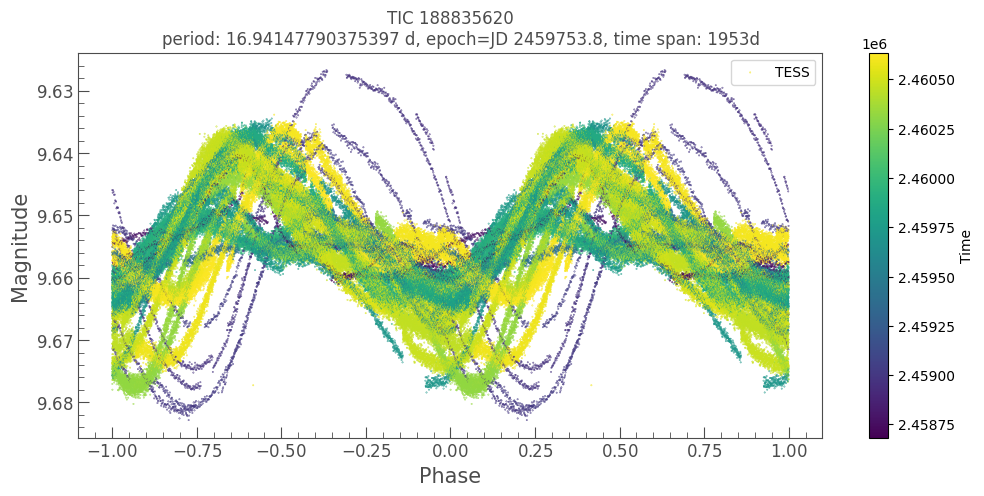

In [31]:
plot_options = lkem.get_default_plot_multi_bands_options_copy()
plot_options[0][1].update(dict(c="_time_"))
                          
for rot_period_trial in [
    # LS values from combined LC    
    # 17.443940889643404, # LS sub-peak 4
    # 16.53407911250366, # LS sub-peak 3 
    # 15.205378782017462, # LS sub-peak 2
    16.94147790375397, # LS peak , the best among them

]: 
    rot_epoch_time_hjd_trial = 2458995.0  #  inspection in lC
    
    ax, lc_f_res = lkem.fold_n_plot_multi_bands(
        lc_combined_dict_no_ecl,
        period=rot_period_trial,
        epoch=Time(rot_epoch_time_hjd_trial, format="jd", scale="utc"),
        phase_scale=2,  #  fold at  period, i.e., plot from phase -1 to +1    
        figsize=(12, 5),
        target_name=primary_name,
        plot_options=plot_options,
    );
    # ax.set_ylim(7.15, 7.05)

    # _lc = lc_f_res["TESS"]
    # ax = tplt.scatter(_lc, s=0.1, alpha=0.5, c=_lc.time_original.value);
    # ax.set_title(f"Period: {_lc.period}");

print("Final adopted rot_period_trial:", rot_period_trial)

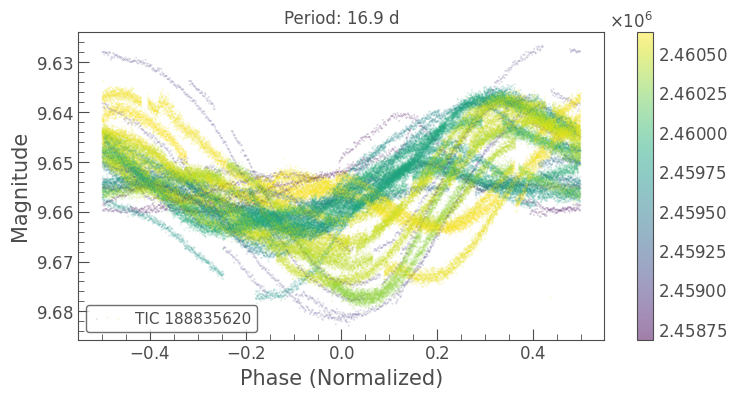

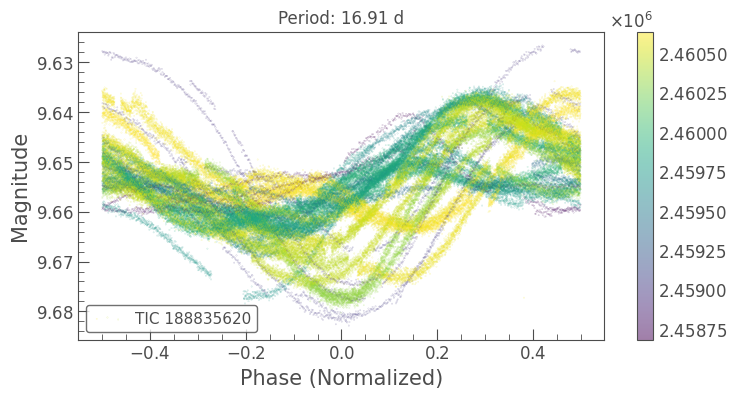

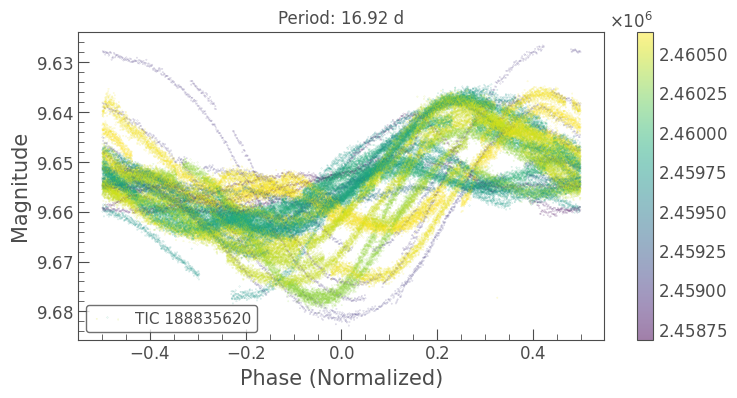

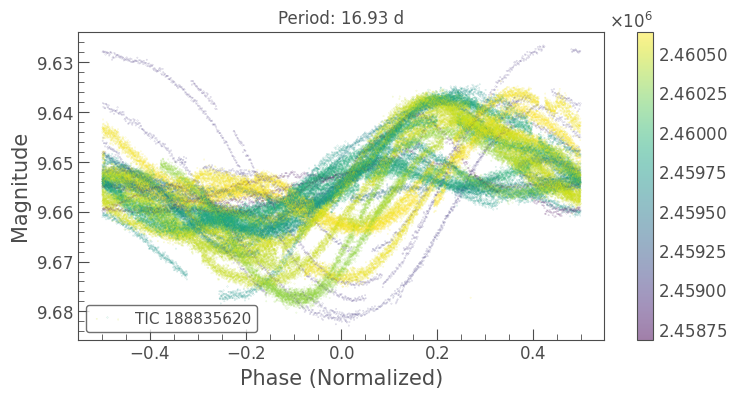

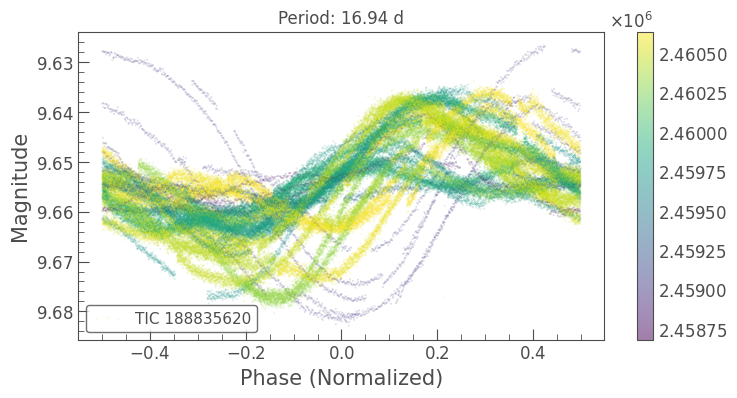

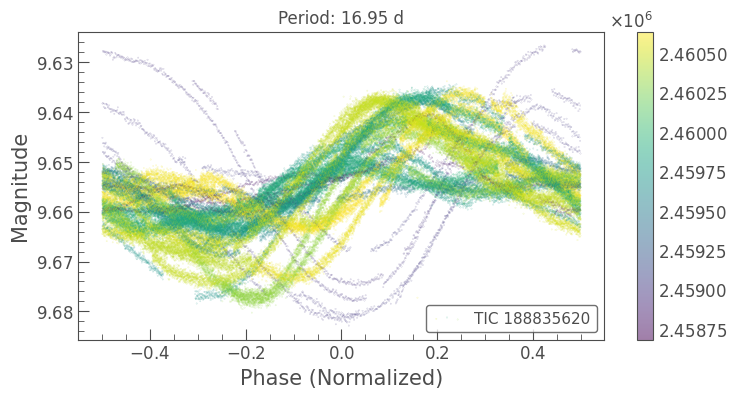

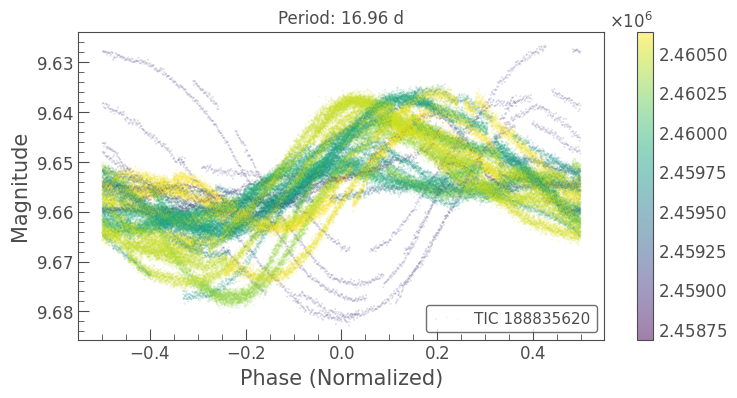

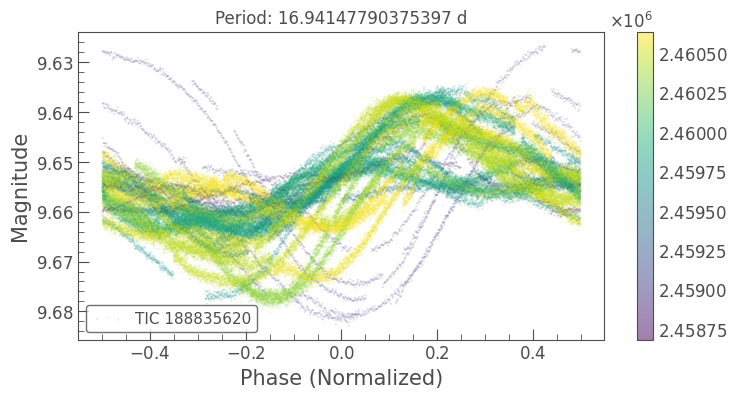

In [50]:
for rot_period_trial in [
    # manuall search around LS peak
    16.90,
    16.91,
    16.92,
    16.93,
    16.94,
    16.95,
    16.96,    
    16.94147790375397, # LS global peak
]: 
    rot_epoch_time_hjd_trial = 2458995.0
    
    _lc = lc_combined_dict_no_ecl["TESS"].fold(epoch_time=rot_epoch_time_hjd_trial, period=rot_period_trial, normalize_phase=True)
    ax = tplt.scatter(_lc, s=0.1, alpha=0.5, c=_lc.time_original.value);
    ax.set_title(f"Period: {_lc.period}");

# 16.91 seems to look better
# print("Final adopted rot_period_trial:", rot_period_trial)

#### Refine the ROT period with MCMC

- not quite precise: the `cosh` Gaussian model is symmetric in shape, while the ROT is not quite

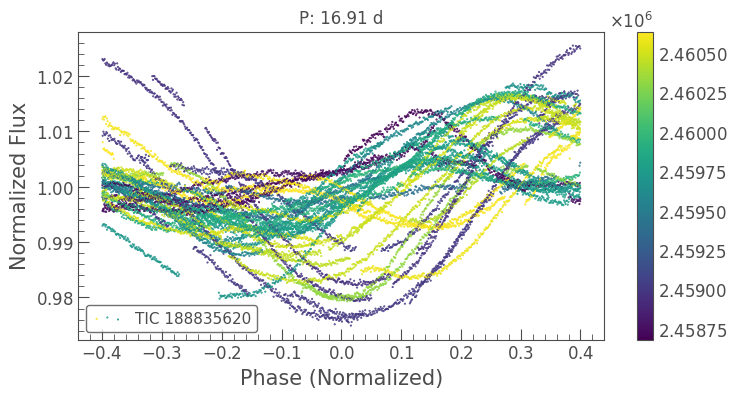

In [53]:
# _lc = lke.to_normalized_flux_from_mag(lc_combined_dict_no_ecl["TESS"].remove_nans())
_lc_binned = lke.bin_flux(lc_combined_dict_no_ecl["TESS"], time_bin_size=30*u.min)   # bin the data from 2 min to 30min , to make MCMC run faster.
_lc = lke.to_normalized_flux_from_mag(_lc_binned.remove_nans().remove_nans(column="flux_err"))

_lc_f_rot_min_i = _lc.fold(epoch_time=rot_epoch_time_hjd_trial, period=16.91, normalize_phase=True)
_lc_f_rot_min_i = _lc_f_rot_min_i.truncate(-0.4, 0.4)
ax1 = tplt.scatter(_lc_f_rot_min_i, c=_lc_f_rot_min_i.time_original.value, s=1);
# ax1 = tplt.errorbar(_lc_f_rot_min_i);
ax1.set_title(f"P: {_lc_f_rot_min_i.period}");


In [55]:
from types import SimpleNamespace

import sys
if "../eb_with_diff_sb_period/etv/" not in sys.path:  # for etvp
    sys.path.append("../eb_with_diff_sb_period/etv/")

import etv_functions_with_period as etvp
import etv_functions
# reload(etv_functions)

lc_f = _lc_f_rot_min_i

# # median flux, -eclipse depth, t0, related to duration, related to shape (U or V) 
# # t0 in normalized phase
start_vals = [1.01, -0.027, 0, 0.22, 1.1]

# convert lc to the form needed by fit etv_functions
lc_f_data = SimpleNamespace(time=lc_f.time_original.value, phase=lc_f.time.value, flux=np.array(lc_f.flux.value), err=np.array(lc_f.flux_err.value))
etv_functions.plot_initial_guess_interactive(lc_f_data, None, None, None, "0", *start_vals)

Output(layout=Layout(padding='1em 0px'), outputs=({'output_type': 'display_data', 'data': {'text/plain': '<Fig…

Output(layout=Layout(padding='1em'), outputs=({'name': 'stdout', 'text': '[1.01, -0.027, 0, 0.22, 1.1]\n\n', '…

100%|██████████| 2000/2000 [15:51<00:00,  2.10it/s]
The chain is shorter than 20 times the integrated autocorrelation time for 3 parameter(s). Use this estimate with caution and run a longer chain!
N/20 = 100;
tau: [ 31.75103421  20.43287909 136.1448856  103.90280592 136.15042979
  24.91607806]


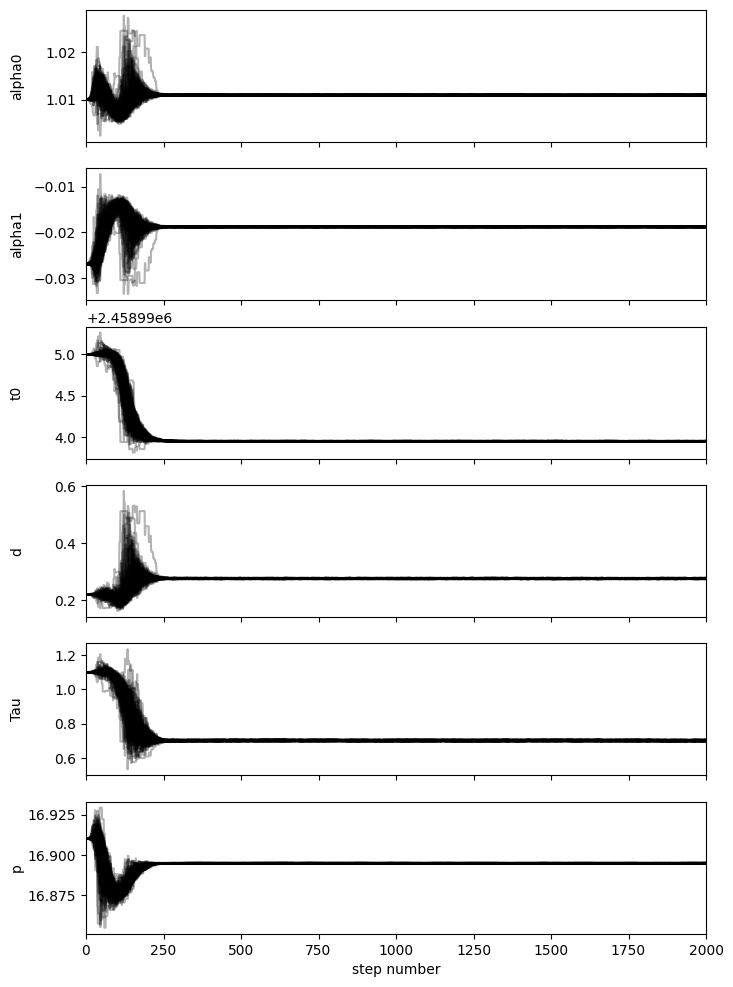

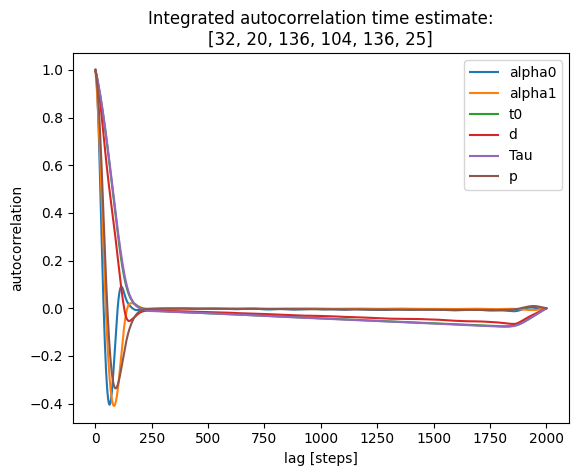

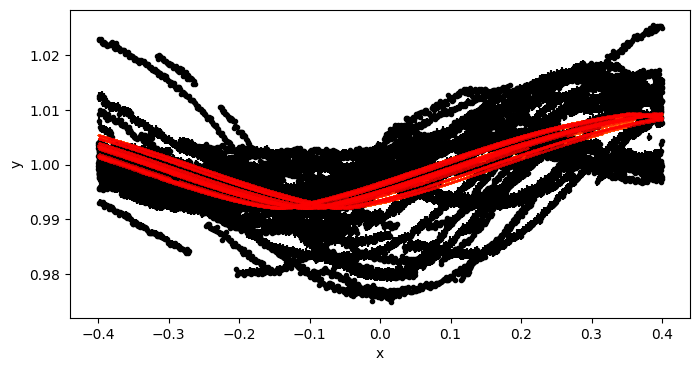

mean_alpha0, mean_alpha1, mean_t0_time, mean_d, mean_Tau, mean_p = 1.010954277004795, -0.018836071636048734, 2458993.949933651, 0.2757780382670011, 0.7017293957607605, 16.894861769520965
std_t0: 0.0019048532981420713
std_p: 5.287871857742728e-05


In [58]:
mean_alpha0, mean_alpha1, mean_t0_time, mean_d, mean_Tau, mean_p, fit_params_p_stats  = etvp.run_mcmc_initial_fit_p(
    lc_f_data, 
    [1.01, -0.027, rot_epoch_time_hjd_trial, 0.22, 1.1, rot_period_trial],
    # nruns=20, discard=1,
    # nruns=1000, discard=400,
    nruns=2000, discard=1000,
    autocorr_time_kwargs=dict(tol=20),  # the emcee defaults tol=50 seems to be too strict for our use case, tol of ~10 - 20 seems to be sufficient    
    pool=-2,
    plot_chains=True, plot_autocorrelation=True, plot=True, 
    also_return_stats=True,
)

print("mean_alpha0, mean_alpha1, mean_t0_time, mean_d, mean_Tau, mean_p = " + ", ".join([str(v) for v in [mean_alpha0, mean_alpha1, mean_t0_time, mean_d, mean_Tau, mean_p]]))
print("std_t0:", fit_params_p_stats["std_t0"])
print("std_p:", fit_params_p_stats["std_p"])


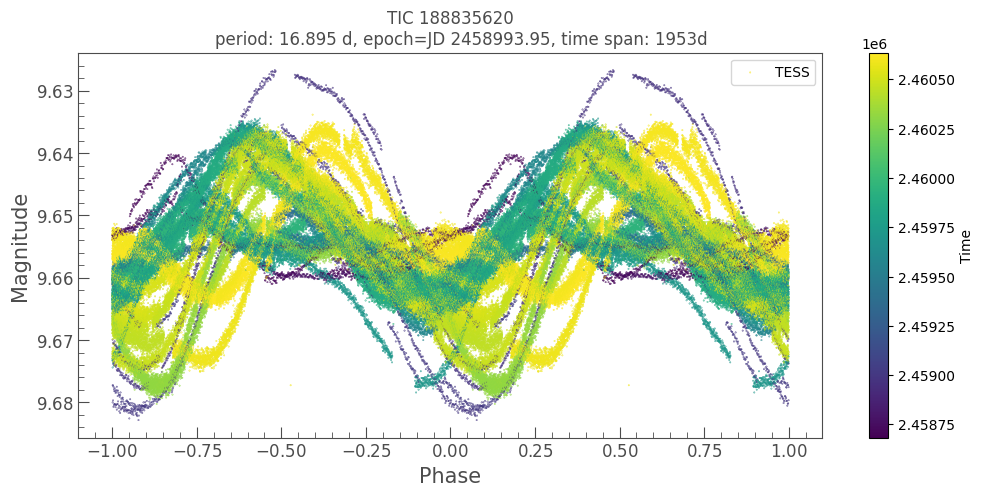

In [60]:
for rot_period_trial in [16.895]: 
    rot_epoch_time_hjd_trial = 2458993.95
    
    ax, lc_f_res = lkem.fold_n_plot_multi_bands(
        lc_combined_dict_no_ecl,
        period=rot_period_trial,
        epoch=Time(rot_epoch_time_hjd_trial   , format="jd", scale="utc"),
        phase_scale=2,  #  fold at  period, i.e., plot from phase -1 to +1    
        figsize=(12, 5),
        target_name=primary_name,
        plot_options=plot_options,
    );
    # ax.set_ylim(9.2, 8.75);


#### Refine the ROT period with ANOVA

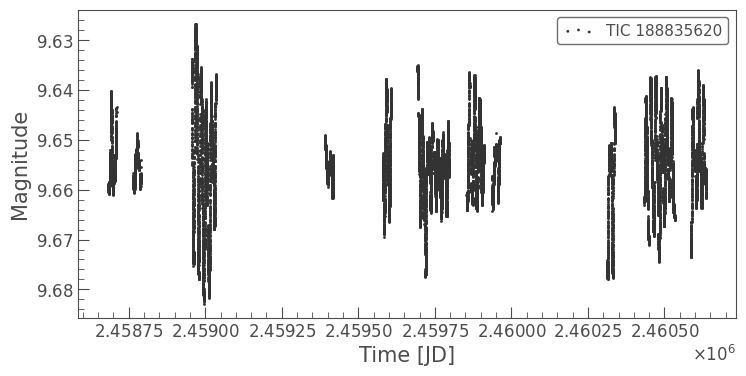

In [47]:
# the best period seems to be around 16.91
# export combined data for period analysis outside the notebook (VStar ANOVA)
# lc = lke.stitch_lc_dict(lc_combined_dict, normalize=False)
lc = lke.bin_flux(lc_combined_dict_no_ecl["TESS"], time_bin_size=30*u.min)   # bin the data from 2 min to 30min , to make MCMC run faster.
lc.remove_columns(["time_bin_start", "time_bin_size"])
lc["source"] = "TESS"
ax = tplt.scatter(lc);

lc.to_pandas().to_csv(f"{lk_download_dir}/tmp_in/tic385464250_no_ecl_tess.csv")


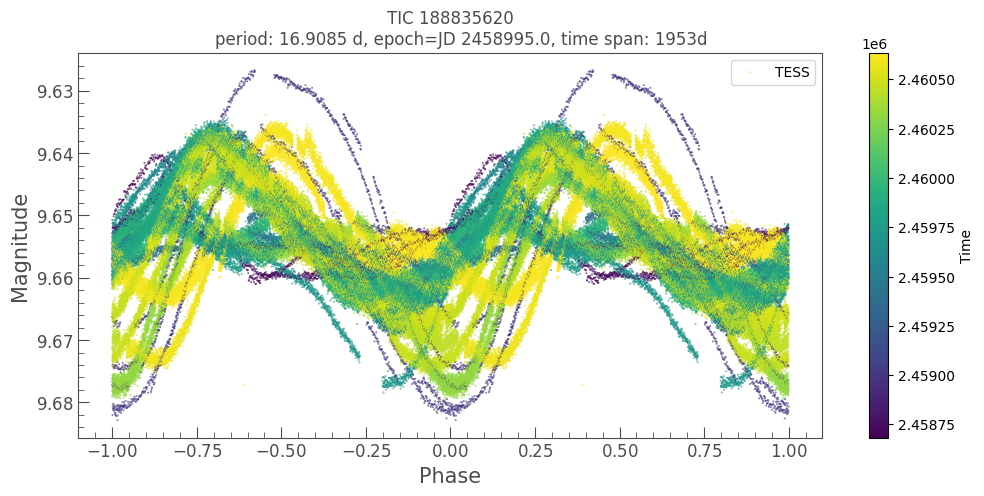

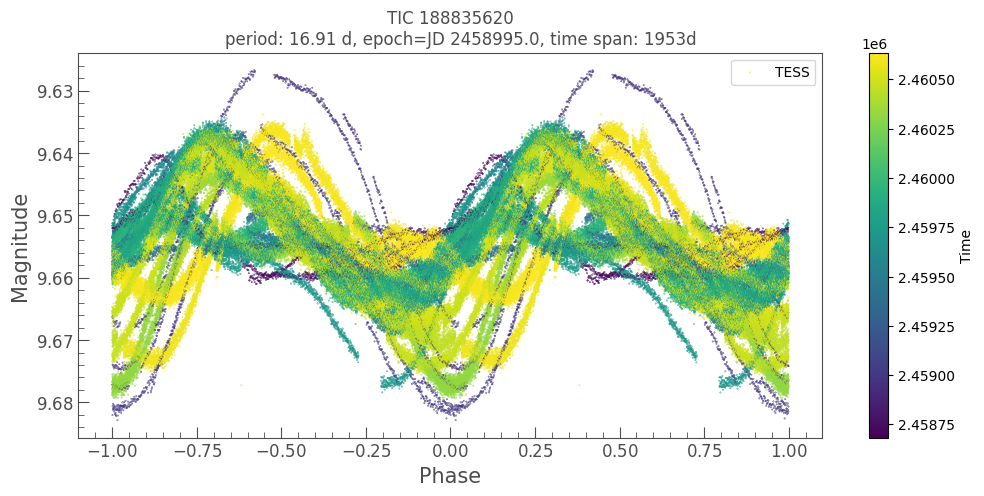

In [52]:
for rot_period_trial in [  # peaks from # VStar ANOVA
    16.9085,
    # ... multiple vals between 16.908 and 16.91 for top 10 20 vals
    16.91,
]: 
    rot_epoch_time_hjd_trial = 2458995.0

    ax, lc_f_res = lkem.fold_n_plot_multi_bands(
        lc_combined_dict_no_ecl,
        period=rot_period_trial,
        epoch=Time(rot_epoch_time_hjd_trial   , format="jd", scale="utc"),
        phase_scale=2,  #  fold at  period, i.e., plot from phase -1 to +1    
        figsize=(12, 5),
        target_name=primary_name,
        plot_options=plot_options,
    );


### Final rotation epoch / period 

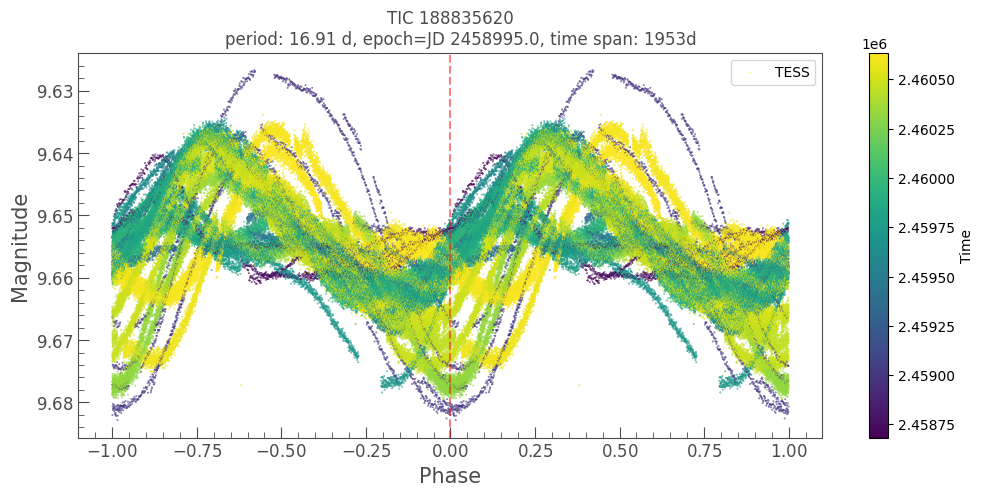

In [78]:
rot_period_final = 16.91  # visually 2 decimals is  enough.  # from ANOVA: 16.9085
rot_epoch_time_hjd_final = 2458995.0  # inspection

plot_options = lkem.get_default_plot_multi_bands_options_copy()
plot_options[0][1].update(dict(c="_time_"))

ax, lc_f_res = lkem.fold_n_plot_multi_bands(
    lc_combined_dict_no_ecl,
    period=rot_period_final, # shorter period, around 2.9207, would make MASCARA and TESS data fit better, but at the expanse of Hipparocos, and TESS-only data
    epoch=Time(rot_epoch_time_hjd_final   , format="jd", scale="utc"),
    phase_scale=2,  #  fold at  period, i.e., plot from phase -1 to +1    
    figsize=(12, 5),
    target_name=primary_name,
    plot_options=plot_options,
);
ax.axvline(0, color="red", alpha=0.5, linestyle="--");
# ax.set_ylim(7.15, 7.05);

# _lc = lc_f_res["TESS"]
# ax = tplt.scatter(_lc, s=0.1, alpha=0.5, c=_lc.time_original.value);
# ax.set_title(f"Period: {_lc.period}");

## Amplitudes

### Overall amplitude and eclipse amplitudes (TESS)

Absolute max: 9.626676 , 99.5 percentile: 9.636221
Min I mag # num data points: 36
Min II mag # num data points: 32
['9.6555', '9.7246', '9.6555', '9.6700']
(np.float64(0.069), np.float64(0.014), np.float64(0.117))


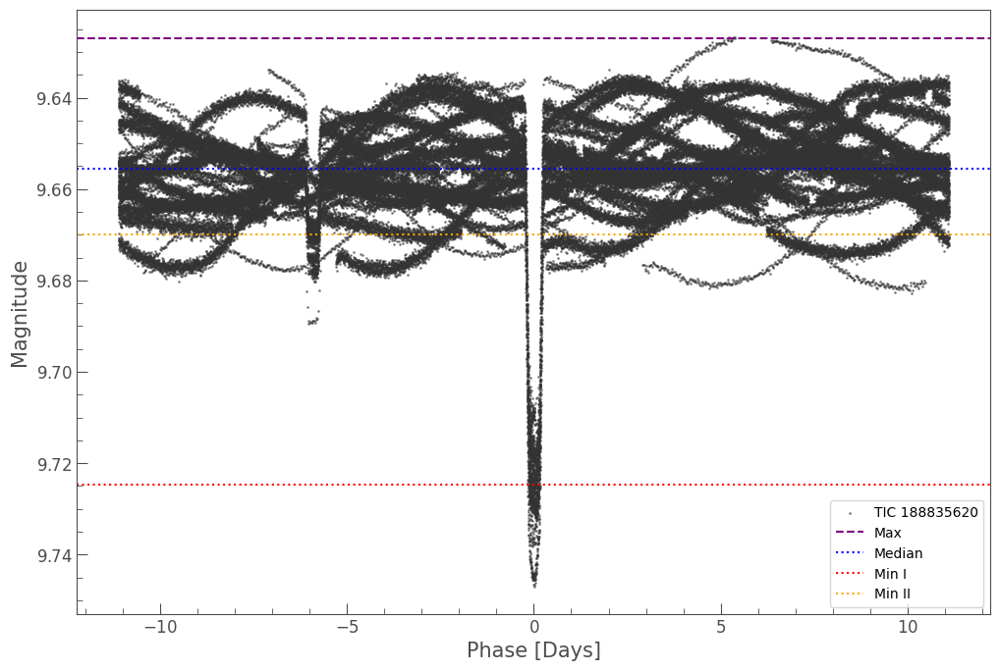

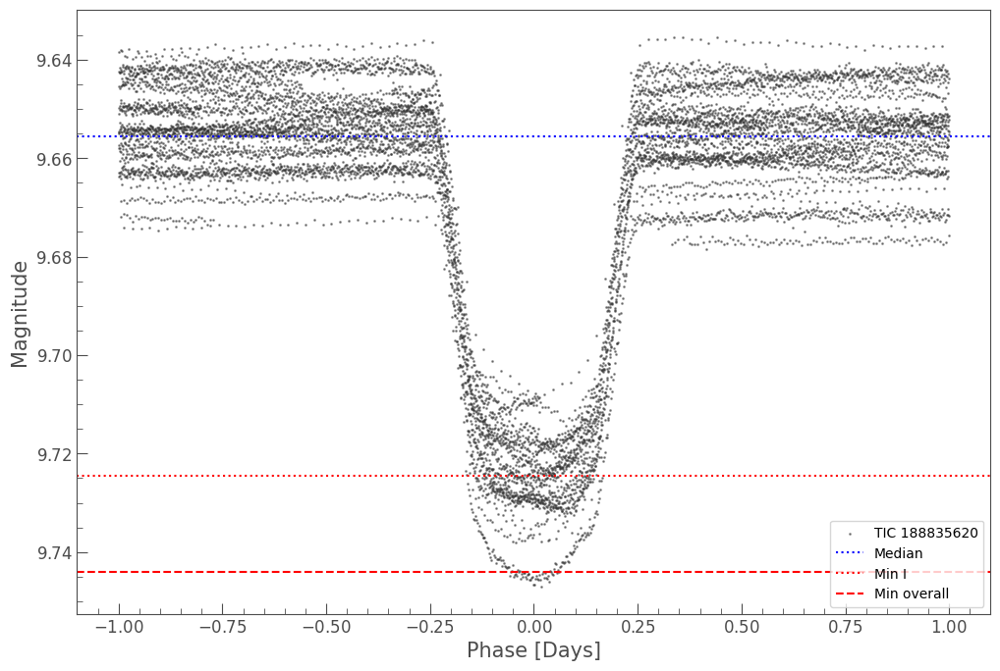

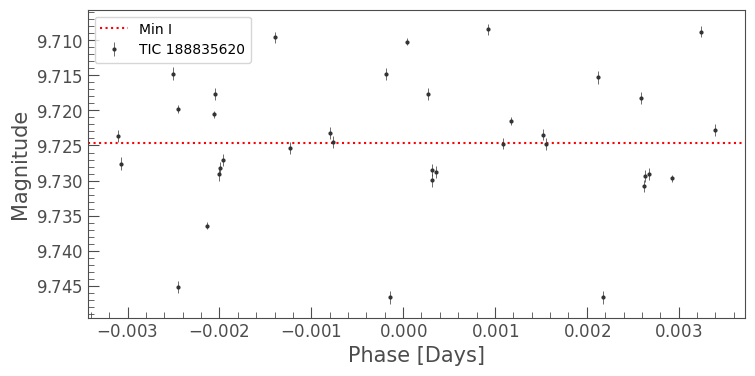

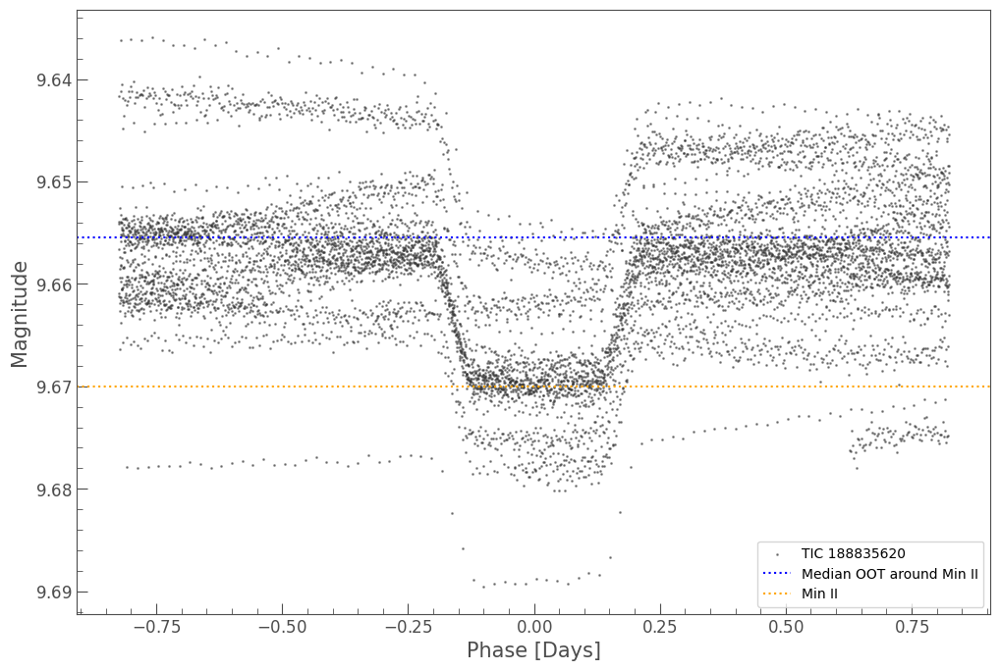

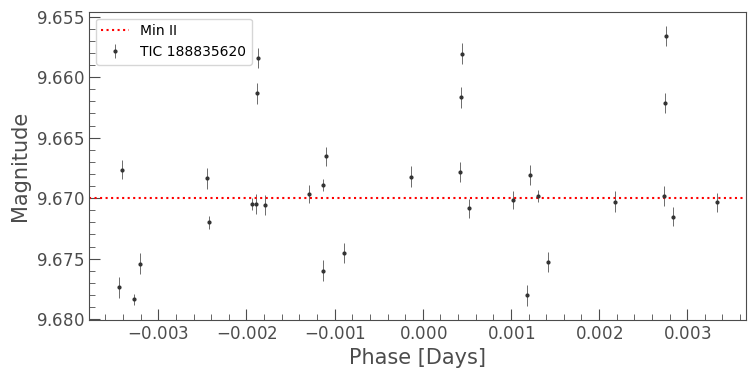

In [75]:
%matplotlib inline

lc = lc_combined_dict["TESS"]

median_flux_mag = np.nanmedian(lc.flux.value)
# median_flux_mag = 8.392  # visual override that fits better as the mag before / after eclipes

# lc_zoom_max = lc.fold(epoch_time=epoch_time_hjd_final + 4.31, period=period_final).truncate(0 - 5 /24/60, 0 + 5 /24/ 60)  # the offset is from above cell
# print("Max mag # num data points:", len(lc_zoom_max))
# max_flux_mag = np.nanmedian(lc_zoom_max.flux.value)
print("Absolute max:", np.nanmin(lc.flux.value), ", 99.5 percentile:", np.nanpercentile(lc.flux.value, 0.5))
max_flux_mag = 9.627  # visual 

lc_zoom_min = lc.fold(epoch_time=epoch_time_hjd_final, period=period_final).truncate(0 - 5 /24/60, 0 + 5 /24/ 60)
print("Min I mag # num data points:", len(lc_zoom_min))
min_i_flux_mag = np.nanmedian(lc_zoom_min.flux.value)

# overall min (not just min i) 
min_flux_mag = 9.744

oot_min_ii_flux_mag = median_flux_mag  # the median surrounding Min II, to calc Min II amp
lc_zoom_min_ii = lc.fold(epoch_time=epoch_time_min_ii_hjd_final, period=period_final).truncate(0 - 5 /24/60, 0 + 5 /24/ 60)
print("Min II mag # num data points:", len(lc_zoom_min_ii))
min_ii_flux_mag = np.nanmedian(lc_zoom_min_ii.flux.value)


# overall 
lc_f = lc.fold(epoch_time=epoch_time_hjd_final, period=period_final)
ax = tplt.lk_ax(figsize=(12, 8))
ax = tplt.scatter(lc_f, ax=ax, alpha=0.5);
ax.axhline(max_flux_mag, c="purple", linestyle="--", label="Max")
ax.axhline(median_flux_mag, c="blue", linestyle="dotted", label="Median")
ax.axhline(min_i_flux_mag, c="red", linestyle="dotted", label="Min I")
ax.axhline(min_ii_flux_mag, c="orange", linestyle="dotted", label="Min II")
ax.legend(loc="lower right");
# ax.set_xlim(-0.5, 0.5); 
ylim = (None, None)
ax.set_ylim(*ylim);


# zoom around pri
lc_f = lc.fold(epoch_time=epoch_time_hjd_final, period=period_final)
lc_f = lc_f.truncate(-duration_hr_min_i_final * 2 / 24, duration_hr_min_i_final * 2 / 24)
ax = tplt.lk_ax(figsize=(12, 8))
ax = tplt.scatter(lc_f, ax=ax, alpha=0.5);
# ax.axhline(max_flux_mag, c="purple", linestyle="--", label="Max")
ax.axhline(median_flux_mag, c="blue", linestyle="dotted", label="Median")
ax.axhline(min_i_flux_mag, c="red", linestyle="dotted", label="Min I")
ax.axhline(min_flux_mag, c="red", linestyle="--", label="Min overall")
ax.legend(loc="lower right");
# ax.set_xlim(-0.5, 0.5); 
ax.set_ylim(*ylim);

# Just Min I (phase 0)
ax = tplt.errorbar(lc_zoom_min, marker="o");
ax.axhline(min_i_flux_mag, c="red", linestyle="dotted", label="Min I")
# ax.set_ylim(*ylim);
ax.legend();



# zoom around secondary
lc_f = lc.fold(epoch_time=epoch_time_min_ii_hjd_final, period=period_final)
lc_f = lc_f.truncate(-duration_hr_min_ii_final * 2 / 24, duration_hr_min_ii_final * 2 / 24)
ax = tplt.lk_ax(figsize=(12, 8))
ax = tplt.scatter(lc_f, ax=ax, alpha=0.5);
# ax.axhline(max_flux_mag, c="purple", linestyle="--", label="Max")
ax.axhline(oot_min_ii_flux_mag, c="blue", linestyle="dotted", label="Median OOT around Min II")
ax.axhline(min_ii_flux_mag, c="orange", linestyle="dotted", label="Min II")
ax.legend(loc="lower right");
# ax.set_xlim(-0.5, 0.5); 
ax.set_ylim(*ylim);

# Just Min II 
ax = tplt.errorbar(lc_zoom_min_ii, marker="o");
ax.axhline(min_ii_flux_mag, c="red", linestyle="dotted", label="Min II")
# ax.set_ylim(*ylim);
ax.legend();

print([f"{v:.4f}" for v in [median_flux_mag, min_i_flux_mag, oot_min_ii_flux_mag, min_ii_flux_mag ]])


# ampitude
amp_min_i_flux_mag = np.round(np.abs(float(min_i_flux_mag - median_flux_mag)) , 3)   # not confident with 3rd digit
amp_min_ii_flux_mag = np.round(np.abs(float(min_ii_flux_mag - oot_min_ii_flux_mag)) , 3)   # not confident with 3rd digit

amp_total_flux_mag = np.round(np.abs(float(min_flux_mag - max_flux_mag)), 3)

print((amp_min_i_flux_mag, amp_min_ii_flux_mag, amp_total_flux_mag))


### Rotational Ampltiude (TESS)

0.054


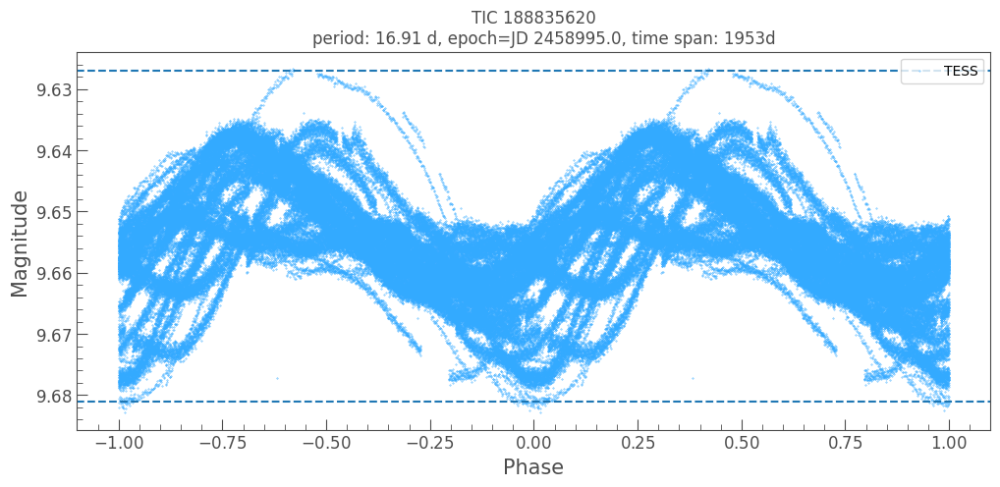

In [82]:
ax, lc_f_res = lkem.fold_n_plot_multi_bands(
    {"TESS": lc_combined_dict_no_ecl["TESS"]},
    period=rot_period_final, # shorter period, around 2.9207, would make MASCARA and TESS data fit better, but at the expanse of Hipparocos, and TESS-only data
    epoch=Time(rot_epoch_time_hjd_final   , format="jd", scale="utc"),
    phase_scale=2,  #  fold at  period, i.e., plot from phase -1 to +1    
    figsize=(12, 5),
    target_name=primary_name,
    # plot_options=plot_options,
);

rot_max_flux_mag, rot_min_flux_mag = 9.627, 9.681
ax.axhline(rot_max_flux_mag, ls="--", label="max ROT");
ax.axhline(rot_min_flux_mag, ls="--", label="min ROT");

amp_rot_flux_mag = round(rot_min_flux_mag - rot_max_flux_mag, 3)
print(amp_rot_flux_mag)

## Plots for VSX

In [83]:
def report_to_df(report):
    df = pd.DataFrame()
    df["Field"] = report.keys()
    df["Value"] = report.values()
    return df


def vsx_phase(phase):
    # the phase I used above is from [-0.5, +0.5]
    # convert to the phase [0, 1[ used by VSX
    if phase < -0.5 or phase > 0.5:
        raise ValueError(f"Input phase needs to be in [-0.5, 0.5] range. Actual: {phase}")
    if phase >= 0:
        return phase 
    else: 
        return 1 + phase


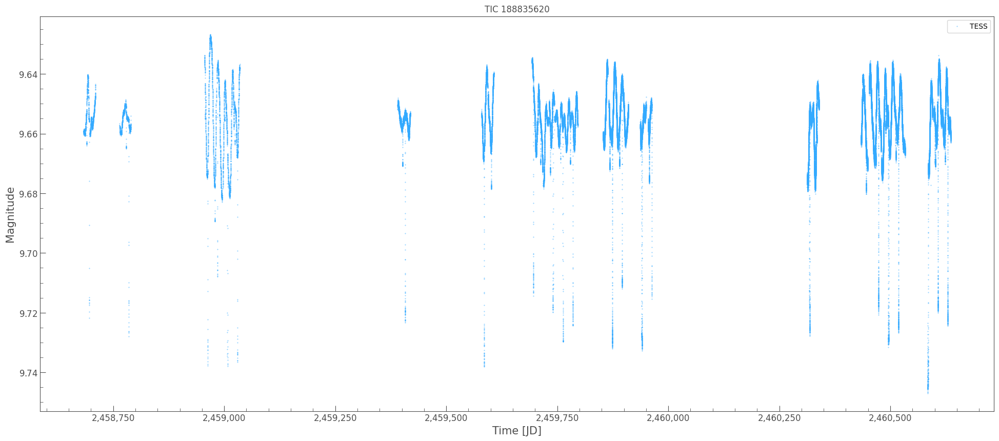

In [84]:
# reload(lkem)
plot_options = lkem.get_default_plot_multi_bands_options_copy()

ax = lkem.plot_multi_bands(lc_combined_dict, figsize=(24, 10), target_name=primary_name, plot_options=plot_options);
ax.set_title(ax.get_title() + "");
ylim = (None, None)
ax.set_ylim(*ylim);

### Phase Plot - EA


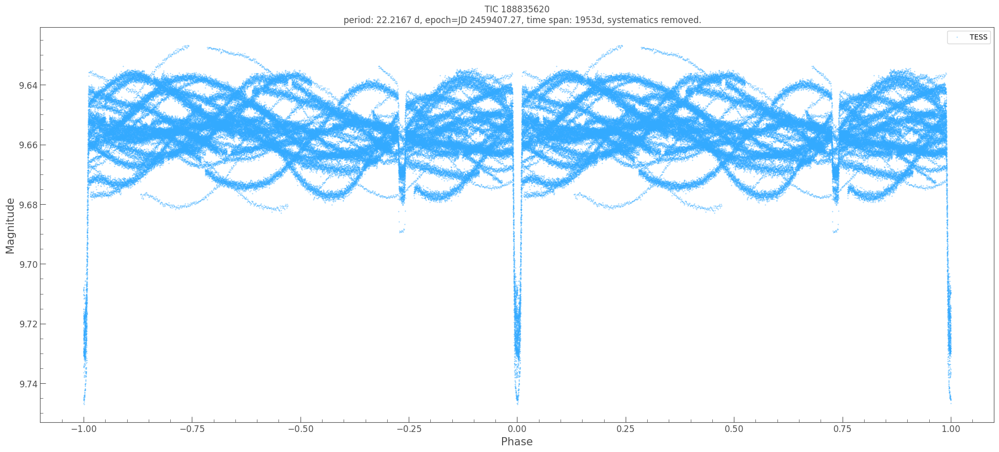

In [87]:
# reload(lkem)

plot_options = lkem.get_default_plot_multi_bands_options_copy()

ax, lc_f_res = lkem.fold_n_plot_multi_bands(
    lc_combined_dict,
    period=period_final,
    epoch=Time(epoch_time_hjd_final , format="jd", scale="utc"),
    phase_scale=2,  #  fold at  period, i.e., plot from phase -1 to +1    
    figsize=(24, 10),
    target_name=primary_name,
    plot_options=plot_options,
);
# ylim = (7.25, 7.0)
# ax.set_ylim(*ylim);
ax.set_title(ax.get_title() + ", systematics removed.");


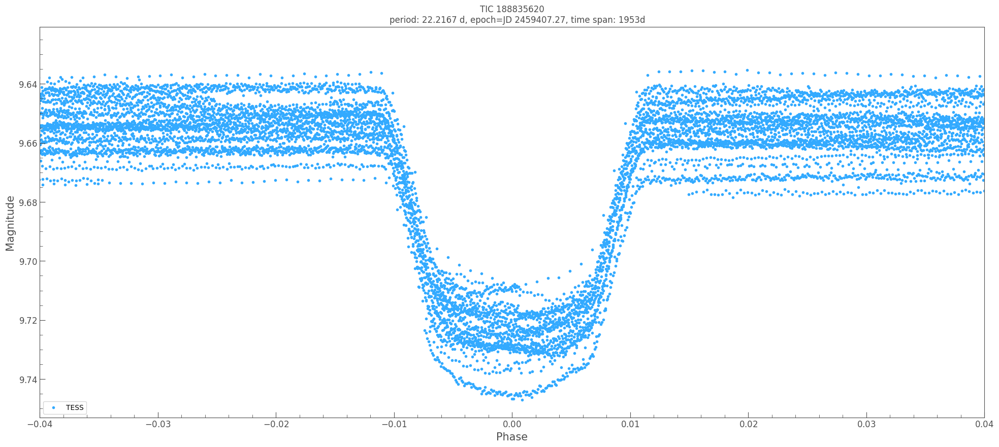

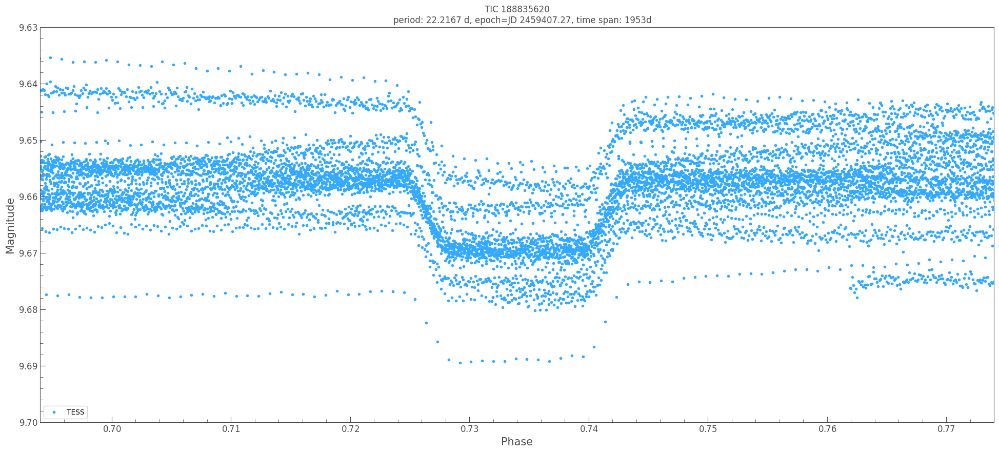

In [112]:
# zoom plot Min I
# - make TESS more visible:  larger dots
plot_options_zoom = lkem.get_default_plot_multi_bands_options_copy()
plot_options_zoom[0][1]["s"] = 9  # larger dots for TESS

# # to workaround astropy TypeError: cannot write to unmasked output when doing matplotlib errorbar  plot
# _lc = lc_combined_dict['TESS'].copy()
# _lc.flux_err = _lc.flux_err.filled(np.nan)

ax, lc_f_res = lkem.fold_n_plot_multi_bands(
    lc_combined_dict,
    period=period_final,
    epoch=Time(epoch_time_hjd_final   , format="jd", scale="utc"),
    phase_scale=2,  #  fold at  period, i.e., plot from phase -1 to +1
    target_name=primary_name,
    # duration_hr=duration_hr_min_i_final  ,  # for plotting only
    figsize=(24, 10),
    plot_options=plot_options_zoom,
    # mag_shift_precision=2,  #
);
ax.set_ylim(*ylim);
ax.legend(loc="lower left");
# ax.axvline(0, c="gray", linestyle="dotted");
ax.set_xlim(-0.04, 0.04);  # to see primary in details


# zoom plot Min II
ax, lc_f_res = lkem.fold_n_plot_multi_bands(
    lc_combined_dict,
    period=period_final,
    epoch=Time(epoch_time_hjd_final   , format="jd", scale="utc"),
    phase_scale=2,  #  fold at  period, i.e., plot from phase -1 to +1
    target_name=primary_name,
    figsize=(24, 10),
    plot_options=plot_options_zoom,
    # mag_shift_precision=2,  #
);
ax.set_ylim(*ylim_min_ii);
ax.legend(loc="lower left");
# ax.axvline(0, c="gray", linestyle="dotted");
# SO: plot Min II at phase of [0, 1)
ax.set_xlim(epoch_phase_min_ii_final -0.04, epoch_phase_min_ii_final + 0.04);  # to see secondary  in details

### Phase Plot - ROT

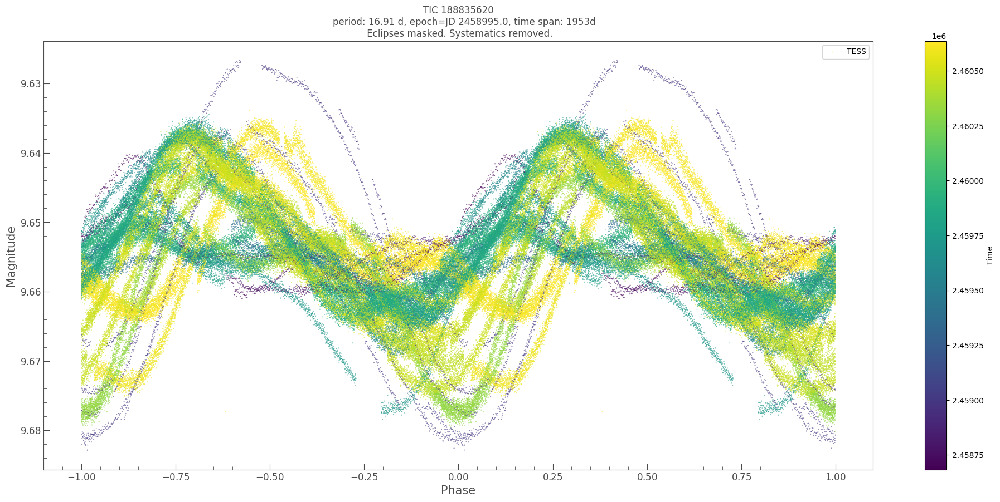

In [118]:
# reload(lkem)

plot_options = lkem.get_default_plot_multi_bands_options_copy()
plot_options[0][1].update(dict(c="_time_"))


ax, lc_f_res = lkem.fold_n_plot_multi_bands(
    lc_combined_dict_no_ecl,
    period=rot_period_final,
    epoch=Time(rot_epoch_time_hjd_final , format="jd", scale="utc"),
    phase_scale=2,  #  fold at  period, i.e., plot from phase -1 to +1    
    figsize=(24, 10),
    target_name=primary_name,
    plot_options=plot_options,
);
# ax.set_ylim(7.2, 7.0);
ax.set_title(ax.get_title() + "\n Eclipses masked. Systematics removed.");


## VSX Report Table

In [95]:
# test the num of digits needed for eclipse duration percent

print(duration_hr_min_i_final / 24 / period_final * 100)
print(duration_hr_min_i_final, period_final * 2.3 / 100 * 24)  # too short
print(duration_hr_min_i_final, period_final * 2.25 / 100 * 24)  # 2 digits needed

2.2505592639770984
12.0 12.263618399999999
12.0 11.997018


In [119]:
import bibs_utils
reload(bibs_utils)

BIBS = bibs_utils.BIBS

# TIC are not added, given the entry refers to thw whole system per SO
other_names = f"TYC 3521-866-1,2MASS J17360735+5207215"  #  ExoFOP and  SIMBAD
other_names += ",UCAC4 711-057834,WISEA J173607.35+520720.6"  # ExoFOP + Vizier -- https://vizier.cds.unistra.fr/viz-bin/VizieR-5?-ref=VIZ6a80bb3f3908a1&-out.add=.&-source=I/322A/out&UCAC4===711-057834  -- https://vizier.cds.unistra.fr/viz-bin/VizieR-5?-ref=VIZ6a80bb5039b033&-out.add=.&-source=II/328/allwise&AllWISE===J173607.35%2b520720.6
other_names += ",GSC 03521-00866"   # Useful IDs from SIMBAD 

remarks = (
    f"""Eccentric system. Min I amplitude: {amp_min_i_flux_mag} TESS. Min II at phase {epoch_phase_min_ii_final}, amplitude: {amp_min_ii_flux_mag} TESS, duration: {duration_hr_min_ii_final / 24 / period_final * 100:.2f}% . """
    f"""ROT elements: HJD {rot_epoch_time_hjd_final} + {rot_period_final} x E , amplitude {amp_rot_flux_mag} TESS. """ 
)  

revision_comment = (
    # "Type, eclipsing period / epoch / duration from TESS data. ROT period / epoch from TESS data. All amplitudes from TESS data. "  #  it seems not to be needed for new submission
    f"Mean magnitude derived from Gaia DR3. Spectral type from {BIBS.GAIA_DR3_ASTROPHY_B}. Position from Gaia DR3."
)


vsx_report = dict(
    Position=f"{target_coord.ra.value:.6f}, {target_coord.dec.value:.6f}",
    Primary_Name=primary_name,
    Other_Names=other_names,
    Variable_Type="EA+ROT",  
    Spectral_Type="G",  # Gaia DR3 astrophysical
    Spectral_Type_Uncertain=False,
    Maximum_Magnitude=f"10.34",  # Gaia DR3 
    Maximum_Magnitude_band="V",
    Minimum_Magnitude=f"{amp_total_flux_mag}",   
    Minimum_Magnitude_band="TESS",  
    Minimum_Is_Amplitude=True,
    Period=f"{period_final}",  
    Epoch=f"{epoch_time_hjd_final:}", 
    Rise_Duration_Pct=f"{duration_hr_min_i_final / 24 / period_final * 100:.2f}",
    Discoverer="Sam Lee, Planet Hunters TESS Collaboration",  # PHT Talk: https://www.zooniverse.org/projects/nora-dot-eisner/planet-hunters-tess/talk/subjects/115174741
    # also identfifed as a variable but without any specifics in TEQUILA catalog of TESS images variables (Ogunwale+, 2025)
    # - only a confidence level score, no epoch / period. So it is ignored
    # - https://vizier.cds.unistra.fr/viz-bin/VizieR-5?-ref=VIZ6a80bba43c502a&-out.add=.&-source=J/A%2bA/704/A317/tequila&recno=6012661
    Remarks=remarks,
    Revision_Comment=revision_comment,
    Reference0_Name=BIBS.QLP_N,
    Reference0_Bib=BIBS.QLP_B,
    Reference6_Name=BIBS.GAIA_DR3_ASTROPHY_N,
    Reference6_Bib=BIBS.GAIA_DR3_ASTROPHY_B,
)


def print_long_fields(report):
    other_names_list = report["Other_Names"].split(",")
    print("Other Names (1 line each):")
    print("\n".join(other_names_list))
    print("")
    print(report["Remarks"])
    print("")
    print(report["Revision_Comment"])

print_long_fields(vsx_report)
with pd.option_context('display.max_colwidth', None):
    display(report_to_df(vsx_report))


# ROT .png file is too large (> 1Mb), saved as jpg 
print("""
tic188835620_phase_plot_eclipses.png : EA Phase Plot - EA Phase Plot from TESS QLP data. Systematics removed.
tic188835620_phase_plot_eclipses_zoom_min_i.png : EA Phase Plot (Min I Zoom) - EA Phase Plot from TESS QLP data. Zoomed around Min I.
tic188835620_phase_plot_eclipses_zoom_min_ii.png : EA Phase Plot (Min II Zoom) - EA Phase Plot from TESS QLP data. Zoomed around Min II.
tic188835620_phase_plot_rot.jpg : Rotation Phase Plot - Rotation Phase Plot from TESS QLP data. Eclipses masked; systematics removed.
""")


Other Names (1 line each):
TYC 3521-866-1
2MASS J17360735+5207215
UCAC4 711-057834
WISEA J173607.35+520720.6
GSC 03521-00866

Eccentric system. Min I amplitude: 0.069 TESS. Min II at phase 0.734, amplitude: 0.014 TESS, duration: 1.86% . ROT elements: HJD 2458995.0 + 16.91 x E , amplitude 0.054 TESS. 

Mean magnitude derived from Gaia DR3. Spectral type from 2023A&A...674A..26C. Position from Gaia DR3.


,Field,Value
0,Position,"264.030644, 52.122595"
1,Primary_Name,TIC 188835620
2,Other_Names,"TYC 3521-866-1,2MASS J17360735+5207215,UCAC4 711-057834,WISEA J173607.35+520720.6,GSC 03521-00866"
3,Variable_Type,EA+ROT
4,Spectral_Type,G
5,Spectral_Type_Uncertain,False
6,Maximum_Magnitude,10.34
7,Maximum_Magnitude_band,V
8,Minimum_Magnitude,0.117
9,Minimum_Magnitude_band,TESS



tic188835620_phase_plot_eclipses.png : EA Phase Plot - EA Phase Plot from TESS QLP data. Systematics removed.
tic188835620_phase_plot_eclipses_zoom_min_i.png : EA Phase Plot (Min I Zoom) - EA Phase Plot from TESS QLP data. Zoomed around Min I.
tic188835620_phase_plot_eclipses_zoom_min_ii.png : EA Phase Plot (Min II Zoom) - EA Phase Plot from TESS QLP data. Zoomed around Min II.
tic188835620_phase_plot_rot.jpg : Rotation Phase Plot - Rotation Phase Plot from TESS QLP data. Eclipses masked; systematics removed.

